# Model 3 — Risk Profile Preprocessing Pipeline
**CEAMIS | Data Science Team**

Pipeline ini memproses data onboarding mentah (backbone 20.000 baris) menjadi dataset siap training untuk **Model 3: Risk Profile Classification**.

---
### Alur Notebook

| # | Tahap | Keterangan |
|---|-------|-----------|
| 0 | Setup & Import | Library, konstanta global |
| 1 | Pertanyaan Bisnis | 9 pertanyaan bisnis CEAMIS yang dijawab oleh pipeline ini |
| 2 | Data Wrangling | Gathering → Assessing → Cleaning |
| 3 | EDA Raw | Eksplorasi sebelum feature engineering |
| 4 | Feature Engineering | Derive kolom onboarding wajib Model 3 |
| 5 | Label Generation | CEAMIS Risk Score → risk_label |
| 6 | Encoding | Label & One-Hot Encoding |
| 7 | Seleksi Kolom Final | Output siap pakai |
| 8 | Quality Assurance | Validasi distribusi & konsistensi |
| 9 | EDA Post-Processing | Visualisasi setelah feature engineering |
| 10 | Data Dictionary | Referensi lengkap semua kolom |
| 11 | Train-Test Split & Export | Export CSV |
| 12 | Feature Reference | Siap pakai untuk AI Engineer |

> **Catatan Mata Uang:** Semua nilai moneter dalam dataset asli (rupee India) telah dikonversi ke **Rupiah Indonesia (IDR)** menggunakan kurs tetap: **1 USD = Rp 16.000** dan **1 INR ≈ Rp 192** (mengikuti estimasi konversi 1 USD = 83 INR).


## 0. Setup & Import

In [46]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Konversi Mata Uang ─────────────────────────────────────────────────────
# Data asli dalam INR (Rupee India)
# Kurs: 1 USD = Rp 16.000 | 1 USD = 83 INR → 1 INR = Rp 16.000/83 ≈ Rp 192.77
INR_TO_IDR = 16_000 / 83  # ≈ 192.77

# ── Global plot style ──────────────────────────────────────────────────────
PALETTE   = {'Konservatif': '#3B82F6', 'Moderat': '#F59E0B', 'Agresif': '#EF4444'}
PALETTE3  = ['#3B82F6', '#F59E0B', '#EF4444']
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize'  : 12,
})

def fmt_idr(x, pos=None):
    """Formatter untuk axis matplotlib dalam Rupiah."""
    if x >= 1_000_000:
        return f'Rp {x/1_000_000:.1f}Jt'
    elif x >= 1_000:
        return f'Rp {x/1_000:.0f}K'
    return f'Rp {x:.0f}'

print('Libraries loaded.')
print(f'Kurs konversi: 1 INR = Rp {INR_TO_IDR:,.2f}')

Libraries loaded.
Kurs konversi: 1 INR = Rp 192.77


---
## 1. Pertanyaan Bisnis

Pipeline ini dirancang untuk menjawab 9 pertanyaan bisnis utama CEAMIS:

| # | Pertanyaan Bisnis | Dijawab Oleh |
|---|------------------|-------------|
| BQ1 | Seberapa sehat kondisi finansial pengguna setiap bulan, dan faktor apa yang paling memengaruhi naik-turunnya skor kesehatan finansial? | `ceamis_score`, EDA Section 9 |
| BQ2 | Segmen pengguna mana yang paling berisiko mengalami kondisi finansial kritis berdasarkan profil awal seperti usia, sumber income, frekuensi income, literasi keuangan, dan jumlah tanggungan? | `risk_label` × `Age`, `Occupation`, `tanggungan_keluarga`, NFWBS |
| BQ3 | Pola pengeluaran apa yang paling sering menyebabkan cashflow negatif, terutama pada kategori needs, wants, saving, dan investment? | `pengeluaran_tetap`, `pengeluaran_variabel`, `disposable_ratio` |
| BQ4 | Apakah pengguna lebih banyak menghabiskan uang pada kebutuhan wajib, keinginan, tabungan, investasi, atau pembayaran utang? | `expense_ratio`, `dti_ratio`, `saving_rate` |
| BQ8 | Rekomendasi seperti apa yang paling efektif untuk meningkatkan saving rate, memperbaiki budget adherence, dan menurunkan risky spending? | `risk_label`, `toleransi_rugi`, `tujuan_keuangan` |
| BQ9 | Pada kondisi seperti apa sistem harus mengaktifkan recovery plan dan warning message agar pengguna bisa bertahan sampai akhir bulan? | `ceamis_score < 0.35`, `dti_ratio > 0.50`, `jumlah_tabungan_bulan < 3` |



---
## 2. Data Wrangling

### 2.1 Gathering Data


In [47]:
# ── Load backbone data ────────────────────────────────────────────────────
BASE_DIR = Path.cwd()
candidates = [
    BASE_DIR / 'data' / 'raw' / 'data.csv',
    BASE_DIR.parent / 'data' / 'raw' / 'data.csv',
    Path('/mnt/data/data.csv'),
]

# ── Load NFWBS data ───────────────────────────────────────────────────────
nfwbs_candidates = [
    BASE_DIR / 'data' / 'raw' / 'NFWBS_PUF_2016_data.csv',
    BASE_DIR.parent / 'data' / 'raw' / 'NFWBS_PUF_2016_data.csv',
    BASE_DIR / 'NFWBS_PUF_2016_data.csv',
    Path('/mnt/data/NFWBS_PUF_2016_data.csv'),
]

data_path = next((p for p in candidates if p.exists()), None)
nfwbs_path = next((p for p in nfwbs_candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        'data.csv tidak ditemukan. Pastikan file berada di folder data/raw/.'
    )
if nfwbs_path is None:
    raise FileNotFoundError(
        'NFWBS_PUF_2016_data.csv tidak ditemukan. Pastikan file berada di folder data/raw/.'
    )

df_raw = pd.read_csv(data_path)
df_nfwbs  = pd.read_csv(nfwbs_path, sep=';')

print(f'data.csv        — Path: {data_path}')
print(f'data.csv        — Shape: {df_raw.shape}')
print(f'NFWBS PUF 2016  — Path: {nfwbs_path}')
print(f'NFWBS PUF 2016  — Shape: {df_nfwbs.shape}')
print(f'\nKolom data.csv  : {df_raw.columns.tolist()}')
df_raw.head(3)


data.csv        — Path: d:\Tugas Kampus\SEMESTER 6\DICODING ERAA!!\data_onboarding\data_onboarding_percobaan\data\raw\data.csv
data.csv        — Shape: (20000, 27)
NFWBS PUF 2016  — Path: d:\Tugas Kampus\SEMESTER 6\DICODING ERAA!!\data_onboarding\data_onboarding_percobaan\data\raw\NFWBS_PUF_2016_data.csv
NFWBS PUF 2016  — Shape: (6394, 217)

Kolom data.csv  : ['Income', 'Age', 'Dependents', 'Occupation', 'City_Tier', 'Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare', 'Education', 'Miscellaneous', 'Desired_Savings_Percentage', 'Desired_Savings', 'Disposable_Income', 'Potential_Savings_Groceries', 'Potential_Savings_Transport', 'Potential_Savings_Eating_Out', 'Potential_Savings_Entertainment', 'Potential_Savings_Utilities', 'Potential_Savings_Healthcare', 'Potential_Savings_Education', 'Potential_Savings_Miscellaneous']


,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422


### 2.2 Assessing Data — Missing Values, Duplikat, Tipe Data

In [48]:
# ── Assessment ────────────────────────────────────────────────────────────
df = df_raw.copy()

print('=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing values. ✓')

print(f'\n=== DUPLIKAT ===')
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')

print(f'\n=== SHAPE ===')
print(f'Baris: {df.shape[0]:,} | Kolom: {df.shape[1]}')

print(f'\n=== TIPE DATA ===')
print(df.dtypes)

print(f'\n=== STATISTIK DASAR (5 kolom utama) ===')
df[['Income', 'Age', 'Dependents', 'Desired_Savings', 'Disposable_Income']].describe()


=== MISSING VALUES ===
Tidak ada missing values. ✓

=== DUPLIKAT ===
Jumlah baris duplikat: 0

=== SHAPE ===
Baris: 20,000 | Kolom: 27

=== TIPE DATA ===
Income                             float64
Age                                  int64
Dependents                           int64
Occupation                             str
City_Tier                              str
Rent                               float64
Loan_Repayment                     float64
Insurance                          float64
Groceries                          float64
Transport                          float64
Eating_Out                         float64
Entertainment                      float64
Utilities                          float64
Healthcare                         float64
Education                          float64
Miscellaneous                      float64
Desired_Savings_Percentage         float64
Desired_Savings                    float64
Disposable_Income                  float64
Potential_Savings_Groceries  

,Income,Age,Dependents,Desired_Savings,Disposable_Income
count,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000
mean,4.158550e+04,41.031450,1.995950,4982.878416,10647.367257
std,4.001454e+04,13.578725,1.417616,7733.468188,11740.637289
min,1.301187e+03,18.000000,0.000000,0.000000,-5400.788673
25%,1.760488e+04,29.000000,1.000000,1224.932636,3774.894323
50%,3.018538e+04,41.000000,2.000000,2155.356763,7224.890977
75%,5.176545e+04,53.000000,3.000000,6216.309609,13331.950716
max,1.079728e+06,64.000000,4.000000,245504.485208,377060.218482


### 2.3 Konversi Mata Uang: INR → IDR

Data asli berasal dari dataset India (nilai dalam Rupee India / INR). Seluruh kolom moneter dikonversi ke Rupiah Indonesia (IDR) menggunakan kurs:

- **1 USD = Rp 16.000**  
- **1 USD = 83 INR**  
- → **1 INR ≈ Rp 192,77**


In [49]:
# ── Kolom yang perlu dikonversi INR → IDR ──────────────────────────────
MONEY_COLS = [
    'Income', 'Rent', 'Loan_Repayment', 'Insurance', 'Groceries',
    'Transport', 'Eating_Out', 'Entertainment', 'Utilities',
    'Healthcare', 'Education', 'Miscellaneous',
    'Desired_Savings', 'Disposable_Income',
    'Potential_Savings_Groceries', 'Potential_Savings_Transport',
    'Potential_Savings_Eating_Out', 'Potential_Savings_Entertainment',
    'Potential_Savings_Utilities', 'Potential_Savings_Healthcare',
    'Potential_Savings_Education', 'Potential_Savings_Miscellaneous',
]

# Buat kolom baru dengan suffix _IDR, pertahankan kolom asli untuk audit
for col in MONEY_COLS:
    df[f'{col}_IDR'] = (df[col] * INR_TO_IDR).round(0)

# Verifikasi
print('=== SAMPLE KONVERSI (baris pertama) ===')
for col in ['Income', 'Rent', 'Desired_Savings']:
    orig = df[col].iloc[0]
    idr  = df[f'{col}_IDR'].iloc[0]
    print(f'  {col}: {orig:,.2f} INR → Rp {idr:,.0f}')

print(f'\nIncome median: Rp {df["Income_IDR"].median():,.0f}')
print(f'Income mean  : Rp {df["Income_IDR"].mean():,.0f}')

=== SAMPLE KONVERSI (baris pertama) ===
  Income: 44,637.25 INR → Rp 8,604,771
  Rent: 13,391.17 INR → Rp 2,581,431
  Desired_Savings: 6,200.54 INR → Rp 1,195,284

Income median: Rp 5,818,869
Income mean  : Rp 8,016,481


### 2.4 Cleaning Data

In [50]:
# ── Data Cleaning ─────────────────────────────────────────────────────────
n_before = len(df)

# 1. Hapus duplikat
df = df.drop_duplicates().reset_index(drop=True)

# 2. Sanity check nilai moneter > 0
df = df[df['Income'] > 0].reset_index(drop=True)
df = df[df['Disposable_Income'] >= 0].reset_index(drop=True)

# 3. Clip Dependents ke range logis (0–10)
df['Dependents'] = df['Dependents'].clip(0, 10)

# 4. Clip Age ke range onboarding (18–70)
df = df[(df['Age'] >= 18) & (df['Age'] <= 70)].reset_index(drop=True)

n_after = len(df)
print(f'Baris sebelum cleaning : {n_before:,}')
print(f'Baris setelah cleaning : {n_after:,}')
print(f'Baris dihapus          : {n_before - n_after:,}')
print(f'\nShape final: {df.shape}')


Baris sebelum cleaning : 20,000
Baris setelah cleaning : 19,888
Baris dihapus          : 112

Shape final: (19888, 49)


---
## 3. EDA — Eksplorasi Data Raw

EDA dilakukan **sebelum** feature engineering untuk memahami distribusi awal, outlier, dan pola yang relevan dengan Model 3.


### 3.1 Distribusi Demografis

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('EDA 3.1 — Distribusi Demografis (Raw)', fontsize=13, fontweight='bold', y=1.02)

# Age
axes[0].hist(df['Age'], bins=30, color='#3B82F6', edgecolor='white', linewidth=0.6)
axes[0].axvline(df['Age'].median(), color='red', linestyle='--', linewidth=1.2,
                label=f'Median {df["Age"].median():.0f}')
axes[0].set_title('Distribusi Usia')
axes[0].set_xlabel('Usia (tahun)')
axes[0].set_ylabel('Frekuensi')

# Occupation
occ_counts = df['Occupation'].value_counts()
axes[1].bar(occ_counts.index, occ_counts.values, color='#10B981', edgecolor='white')
axes[1].set_title('Distribusi Pekerjaan')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylabel('Frekuensi')
for i, v in enumerate(occ_counts.values):
    axes[1].text(v + 30, i, f'{v:,}', va='center', fontsize=9)

# City Tier
tier_counts = df['City_Tier'].value_counts()
axes[2].pie(tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%',
            colors=['#F59E0B', '#10B981', '#EF4444'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[2].set_title('Distribusi City Tier')

plt.tight_layout()
plt.savefig('eda_01_demografis.png', bbox_inches='tight', dpi=150)
plt.show()


### 3.2 Distribusi Income (IDR) — Skewness & Outlier

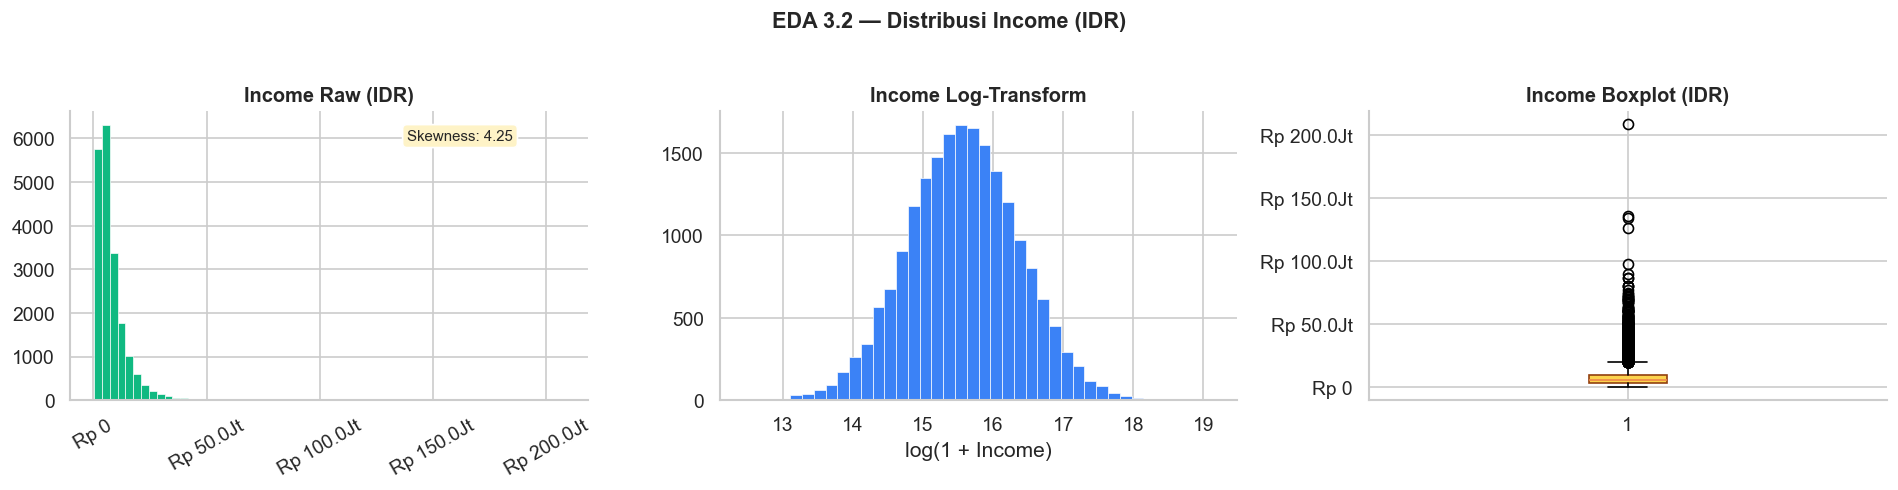

Income (IDR) — Min: Rp 250,831
Income (IDR) — Median: Rp 5,817,756
Income (IDR) — Mean: Rp 8,012,103
Income (IDR) — Max: Rp 208,140,409


In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('EDA 3.2 — Distribusi Income (IDR)', fontsize=13, fontweight='bold', y=1.02)

# Raw histogram
axes[0].hist(df['Income_IDR'], bins=60, color='#10B981', edgecolor='white', linewidth=0.4)
axes[0].set_title('Income Raw (IDR)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_idr))
axes[0].tick_params(axis='x', rotation=30)
skew = df['Income_IDR'].skew()
axes[0].text(0.65, 0.90, f'Skewness: {skew:.2f}', transform=axes[0].transAxes, fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FEF3C7'))
             
# Log-transformed
axes[1].hist(np.log1p(df['Income_IDR']), bins=40, color='#3B82F6', edgecolor='white', linewidth=0.4)
axes[1].set_title('Income Log-Transform')
axes[1].set_xlabel('log(1 + Income)')

# Boxplot
axes[2].boxplot(df['Income_IDR'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#FCD34D', color='#92400E'))
axes[2].set_title('Income Boxplot (IDR)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_idr))

plt.tight_layout()
plt.savefig('../visualisasi/eda_02_income_distribusi.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Income (IDR) — Min: Rp {df["Income_IDR"].min():,.0f}')
print(f'Income (IDR) — Median: Rp {df["Income_IDR"].median():,.0f}')
print(f'Income (IDR) — Mean: Rp {df["Income_IDR"].mean():,.0f}')
print(f'Income (IDR) — Max: Rp {df["Income_IDR"].max():,.0f}')


### 3.3 Expense Breakdown — Komposisi Pengeluaran (IDR)

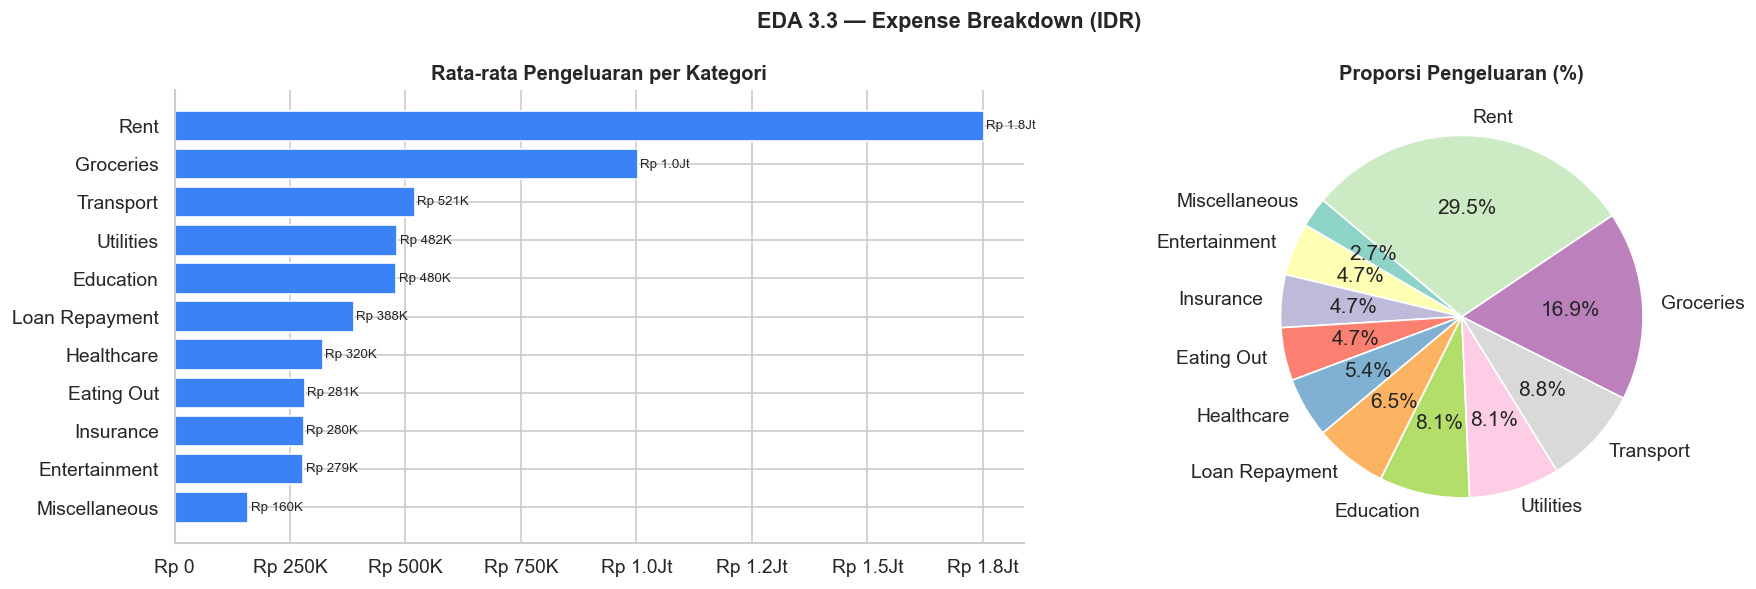

In [55]:
expense_idr_cols = [
    'Rent_IDR', 'Loan_Repayment_IDR', 'Insurance_IDR', 'Groceries_IDR',
    'Transport_IDR', 'Eating_Out_IDR', 'Entertainment_IDR', 'Utilities_IDR',
    'Healthcare_IDR', 'Education_IDR', 'Miscellaneous_IDR'
]

expense_labels = [c.replace('_IDR', '').replace('_', ' ') for c in expense_idr_cols]
expense_means  = df[expense_idr_cols].mean()
expense_means.index = expense_labels
expense_means = expense_means.sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('EDA 3.3 — Expense Breakdown (IDR)', fontsize=13, fontweight='bold')

# Bar chart
bars = axes[0].barh(expense_means.index, expense_means.values, color='#3B82F6', edgecolor='white')
axes[0].set_title('Rata-rata Pengeluaran per Kategori')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_idr))
for bar, val in zip(bars, expense_means.values):
    axes[0].text(val + 5000, bar.get_y() + bar.get_height()/2,
                 fmt_idr(val), va='center', fontsize=8)

# Pie chart
axes[1].pie(expense_means.values, labels=expense_means.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set3', len(expense_means)))
axes[1].set_title('Proporsi Pengeluaran (%)')

plt.tight_layout()
plt.savefig('../visualisasi/eda_03_expense_breakdown.png', bbox_inches='tight', dpi=150)
plt.show()


### 3.4 Correlation Heatmap — Fitur Numerik Raw

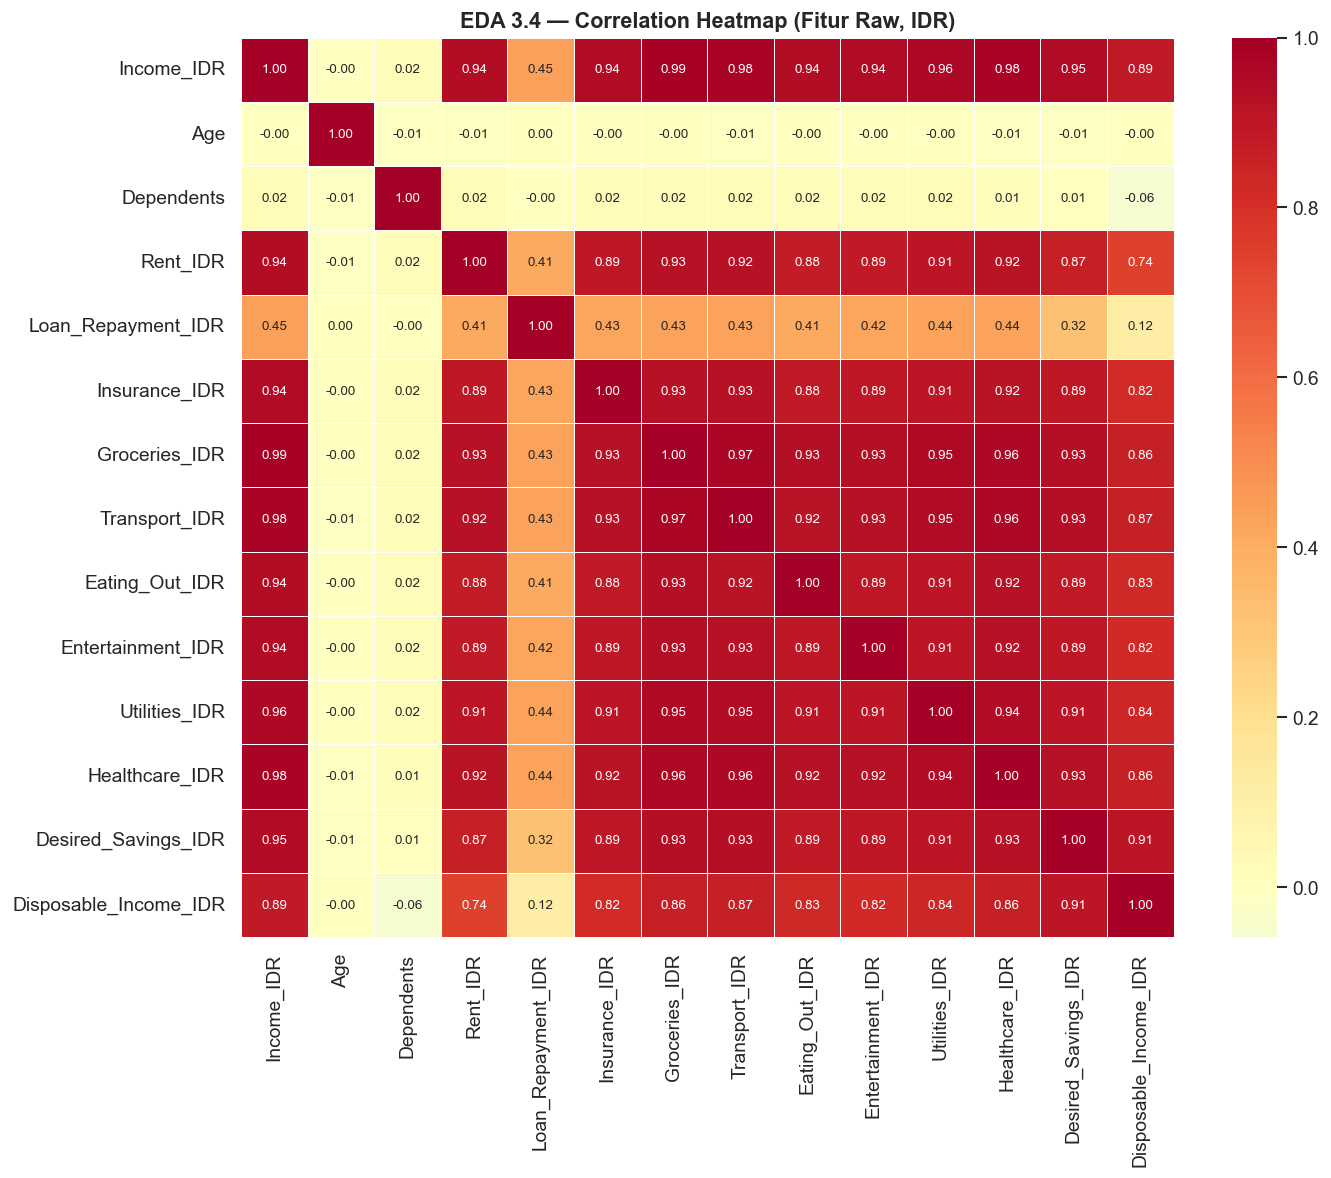

In [56]:
numeric_idr = ['Income_IDR', 'Age', 'Dependents', 'Rent_IDR', 'Loan_Repayment_IDR',
               'Insurance_IDR', 'Groceries_IDR', 'Transport_IDR', 'Eating_Out_IDR',
               'Entertainment_IDR', 'Utilities_IDR', 'Healthcare_IDR',
               'Desired_Savings_IDR', 'Disposable_Income_IDR']

corr = df[numeric_idr].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('EDA 3.4 — Correlation Heatmap (Fitur Raw, IDR)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualisasi/eda_04_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


### 3.5 Missing Value & Outlier Report

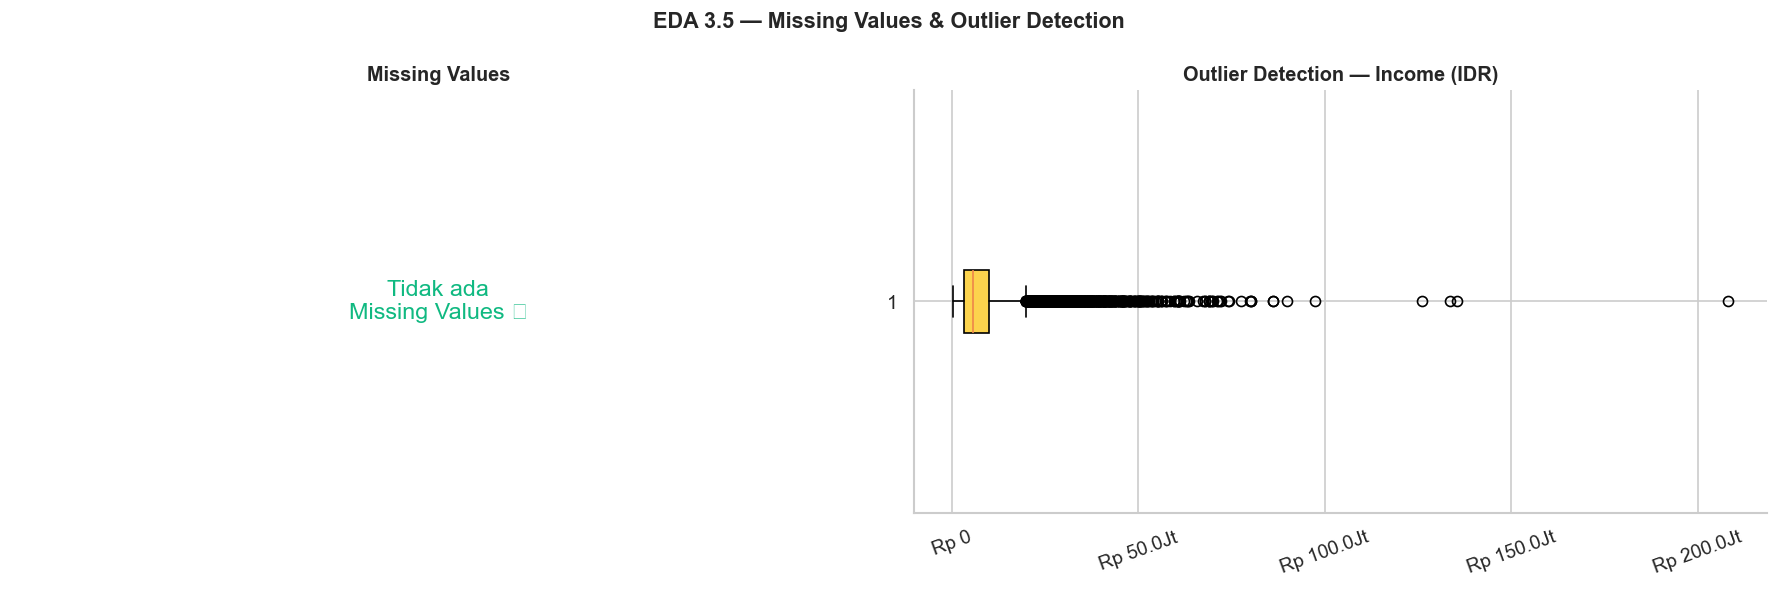

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('EDA 3.5 — Missing Values & Outlier Detection', fontsize=13, fontweight='bold')

# Missing values
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_nonzero = missing_pct[missing_pct > 0]
if len(missing_nonzero) > 0:
    axes[0].barh(missing_nonzero.index, missing_nonzero.values, color='#EF4444')
    axes[0].set_title('Missing Value (%)')
    axes[0].set_xlabel('Missing (%)')
else:
    axes[0].text(0.5, 0.5, 'Tidak ada\nMissing Values ✓',
                 ha='center', va='center', fontsize=14, color='#10B981',
                 transform=axes[0].transAxes)
    axes[0].set_title('Missing Values')
    axes[0].axis('off')

# Boxplot outlier Income
axes[1].boxplot(df['Income_IDR'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='#FCD34D'))
axes[1].set_title('Outlier Detection — Income (IDR)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_idr))
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('../visualisasi/eda_05_missing_outlier.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 4. Feature Engineering — Kolom Onboarding Wajib Model 3

Semua kolom berikut di-derive dari kolom backbone dengan logika bisnis CEAMIS.  
**Semua kolom moneter menggunakan nilai IDR.**


### 4.1 `penghasilan_bulanan` & `pengeluaran_tetap` / `pengeluaran_variabel`

In [58]:
# penghasilan_bulanan: langsung dari Income (sudah dikonversi ke IDR)
df['penghasilan_bulanan'] = df['Income_IDR'].round(0)

# pengeluaran_tetap (IDR): Rent + Loan_Repayment + Insurance + Utilities + Education
fixed_idr_cols = ['Rent_IDR', 'Loan_Repayment_IDR', 'Insurance_IDR', 'Utilities_IDR', 'Education_IDR']
df['pengeluaran_tetap'] = df[fixed_idr_cols].sum(axis=1).round(0)

# pengeluaran_variabel (IDR): Groceries + Transport + Eating_Out + Entertainment + Healthcare + Miscellaneous
variable_idr_cols = ['Groceries_IDR', 'Transport_IDR', 'Eating_Out_IDR',
                     'Entertainment_IDR', 'Healthcare_IDR', 'Miscellaneous_IDR']
df['pengeluaran_variabel'] = df[variable_idr_cols].sum(axis=1).round(0)

# total_pengeluaran
df['total_pengeluaran'] = (df['pengeluaran_tetap'] + df['pengeluaran_variabel']).round(0)

print('=== Statistik Pengeluaran (IDR) ===')
print(df[['penghasilan_bulanan', 'pengeluaran_tetap',
           'pengeluaran_variabel', 'total_pengeluaran']].describe().map(lambda x: f'Rp {x:,.0f}'))


=== Statistik Pengeluaran (IDR) ===
      penghasilan_bulanan pengeluaran_tetap pengeluaran_variabel  \
count           Rp 19,888         Rp 19,888            Rp 19,888   
mean         Rp 8,012,103      Rp 3,382,978         Rp 2,564,211   
std          Rp 7,715,985      Rp 3,409,409         Rp 2,470,840   
min            Rp 250,831         Rp 87,226            Rp 86,758   
25%          Rp 3,393,108      Rp 1,372,441         Rp 1,078,542   
50%          Rp 5,817,756      Rp 2,396,287         Rp 1,856,206   
75%          Rp 9,968,098      Rp 4,202,013         Rp 3,183,448   
max        Rp 208,140,409     Rp 77,442,962        Rp 60,754,942   

      total_pengeluaran  
count         Rp 19,888  
mean       Rp 5,947,188  
std        Rp 5,803,378  
min          Rp 190,540  
25%        Rp 2,476,360  
50%        Rp 4,282,014  
75%        Rp 7,379,854  
max      Rp 135,454,102  


### 4.2 Rasio Keuangan CEAMIS — DTI, Saving Rate, Disposable, Expense

In [59]:
# Debt-to-Income Ratio (DTI): Loan_Repayment / Income (pakai IDR, rasio sama)
df['dti_ratio'] = (df['Loan_Repayment_IDR'] / df['penghasilan_bulanan']).round(4).clip(0, 1)

# Saving Rate: Desired_Savings / Income
df['saving_rate'] = (df['Desired_Savings_IDR'] / df['penghasilan_bulanan']).round(4).clip(0, 1)

# Disposable Income Ratio: Disposable_Income / Income
df['disposable_ratio'] = (df['Disposable_Income_IDR'] / df['penghasilan_bulanan']).round(4).clip(0, 1)

# Expense Ratio: total_pengeluaran / Income
df['expense_ratio'] = (df['total_pengeluaran'] / df['penghasilan_bulanan']).round(4).clip(0, 2)

print('=== Rasio Keuangan ===')
print(df[['dti_ratio', 'saving_rate', 'disposable_ratio', 'expense_ratio']].describe())


=== Rasio Keuangan ===
          dti_ratio   saving_rate  disposable_ratio  expense_ratio
count  19888.000000  19888.000000      19888.000000   19888.000000
mean       0.049143      0.094693          0.256655       0.743345
std        0.066538      0.037980          0.095280       0.095280
min        0.000000      0.000400          0.000400       0.493500
25%        0.000000      0.067300          0.190900       0.671900
50%        0.000000      0.086900          0.265850       0.734150
75%        0.104700      0.115200          0.328100       0.809100
max        0.199900      0.249400          0.506500       0.999600


### 4.3 `punya_tabungan` & `jumlah_tabungan_bulan`

In [60]:
# punya_tabungan: 1 jika Desired_Savings > 0
df['punya_tabungan'] = (df['Desired_Savings_IDR'] > 0).astype(int)

# jumlah_tabungan_bulan: (Desired_Savings * 6) / total_pengeluaran
# Cap 36 bulan (3 tahun)
df['jumlah_tabungan_bulan'] = np.where(
    df['total_pengeluaran'] > 0,
    ((df['Desired_Savings_IDR'] * 6) / df['total_pengeluaran']).clip(0, 36).round(2),
    0
)

print('punya_tabungan distribution:')
print(df['punya_tabungan'].value_counts())
print(f'\njumlah_tabungan_bulan median: {df["jumlah_tabungan_bulan"].median():.2f} bulan')


punya_tabungan distribution:
punya_tabungan
1    19888
Name: count, dtype: int64

jumlah_tabungan_bulan median: 0.71 bulan


### 4.4 `punya_investasi` & `jenis_investasi`

In [61]:
# Proxy investasi berdasarkan disposable_ratio & saving target
investasi_mask = (
    (df['disposable_ratio'] > 0.20) &
    (df['Desired_Savings_Percentage'] > 15)
)
middle_mask = (
    (df['disposable_ratio'] > 0.10) &
    (df['Desired_Savings_Percentage'] > 10) &
    ~investasi_mask
)
rng = np.random.default_rng(RANDOM_SEED)
middle_rand = np.random.rand(len(df)) < 0.70

df['punya_investasi'] = (investasi_mask | (middle_mask & middle_rand)).astype(int)

# Kuantil income untuk rule-based jenis investasi
income_q1 = df['penghasilan_bulanan'].quantile(0.25)
income_q3 = df['penghasilan_bulanan'].quantile(0.75)

def assign_jenis_investasi(row):
    if row['punya_investasi'] == 0:
        return 'tidak_ada'
    inc = row['penghasilan_bulanan']
    occ = row['Occupation']
    if occ == 'Retired':
        return 'deposito_obligasi'
    if inc <= income_q1:
        return 'reksa_dana'
    elif inc <= income_q3:
        return 'saham_reksa_dana' if occ == 'Professional' else 'deposito'
    else:
        return 'saham_obligasi'

df['jenis_investasi'] = df.apply(assign_jenis_investasi, axis=1)

print('punya_investasi:', df['punya_investasi'].value_counts().to_dict())
print('jenis_investasi:')
print(df['jenis_investasi'].value_counts())


punya_investasi: {0: 14857, 1: 5031}
jenis_investasi:
jenis_investasi
tidak_ada            14857
saham_obligasi        2725
deposito_obligasi     1236
deposito               712
saham_reksa_dana       358
Name: count, dtype: int64


### 4.5 `tujuan_keuangan` & `toleransi_rugi`

In [62]:
def assign_tujuan_keuangan(row):
    age = row['Age']
    occ = row['Occupation']
    inc = row['penghasilan_bulanan']
    dep = row['Dependents']
    if occ == 'Student' or age <= 25 or inc < income_q1:
        return 'darurat'
    elif occ == 'Retired' or age >= 50:
        return 'pensiun'
    elif 30 <= age < 50 and dep > 0 and income_q1 <= inc <= income_q3:
        return 'beli_aset'
    elif inc > income_q3 or (occ == 'Professional' and 30 <= age <= 50):
        return 'bebas_finansial'
    else:
        return 'darurat'

df['tujuan_keuangan'] = df.apply(assign_tujuan_keuangan, axis=1)

def assign_toleransi_rugi(row):
    disp = row['disposable_ratio']
    dti  = row['dti_ratio']
    age  = row['Age']
    sr   = row['saving_rate']
    if disp > 0.30 and dti < 0.20 and age < 45 and sr > 0.10:
        return 'tinggi'
    elif disp >= 0.10 and dti < 0.40:
        return 'sedang'
    else:
        return 'rendah'

df['toleransi_rugi'] = df.apply(assign_toleransi_rugi, axis=1)
df['tanggungan_keluarga'] = df['Dependents'].astype(int)

print('tujuan_keuangan:')
print(df['tujuan_keuangan'].value_counts())
print('\ntoleransi_rugi:')
print(df['toleransi_rugi'].value_counts())


tujuan_keuangan:
tujuan_keuangan
darurat            11222
pensiun             5389
beli_aset           1742
bebas_finansial     1535
Name: count, dtype: int64

toleransi_rugi:
toleransi_rugi
sedang    17104
tinggi     1519
rendah     1265
Name: count, dtype: int64


### 4.6 Join Heuristik — NFWBS Behavior Columns

> Pendekatan:
> 1. Bersihkan nilai sentinel `-1` (missing) dari kolom NFWBS target.  
> 2. Petakan `Age` data.csv → `agecat` NFWBS (1-8) dan `Income` → `income_quartile` (1-4 berdasarkan persentil relatif).  
> 3. Hitung distribusi empiris (mean + std) per `agecat × income_quartile` dari NFWBS asli.  
> 4. Untuk setiap baris data.csv, lakukan **random sampling dari distribusi normal** yang dikalibrasi ke statistik empiris tersebut, lalu clip ke range valid masing-masing kolom.
>
> Hasilnya: setiap pengguna mendapat profil perilaku yang **secara statistik konsisten** dengan pola populasi survei riil, bukan nilai buatan.

#### Kolom NFWBS yang di-assign:
| Kolom | Skala | Makna |
|-------|-------|-------|
| `SAVEHABIT` | 1–6 | Kebiasaan menabung (1=tidak pernah, 6=selalu) |
| `SELFCONTROL_1` | 1–4 | Kendali pengeluaran (1=tidak terkontrol, 4=sangat terkontrol) |
| `SCFHORIZON` | 1–5 | Horizon perencanaan keuangan (1=beberapa bulan, 5=10+ tahun) |
| `FINGOALS` | 0–1 | Punya tujuan finansial tertulis (0=tidak, 1=ya) |

In [63]:
# ── Step 1: Bersihkan nilai missing (-1) di NFWBS ────────────────────────
NFWBS_TARGET_COLS = ['SAVEHABIT', 'SELFCONTROL_1', 'SCFHORIZON', 'FINGOALS']
for col in NFWBS_TARGET_COLS:
    df_nfwbs[col] = df_nfwbs[col].replace(-1, np.nan)

print('NFWBS — Missing setelah replace -1:')
print(df_nfwbs[NFWBS_TARGET_COLS].isnull().sum())

# ── Step 2: Buat agecat dan income_quartile di NFWBS ─────────────────────
# agecat sesuai dokumentasi NFWBS: 1=18-24, 2=25-34, ..., 8=75+
# income_quartile: PPINCIMP 1-3 → Q1, 4-5 → Q2, 6-7 → Q3, 8-9 → Q4
def ppincimp_to_quartile(x):
    if x <= 3:   return 1
    elif x <= 5: return 2
    elif x <= 7: return 3
    else:        return 4

df_nfwbs['income_quartile'] = df_nfwbs['PPINCIMP'].apply(ppincimp_to_quartile)

# ── Step 3: Hitung statistik empiris per agecat × income_quartile ─────────
nfwbs_stats = df_nfwbs.groupby(['agecat', 'income_quartile'])[NFWBS_TARGET_COLS].agg(['mean', 'std'])
nfwbs_stats.columns = ['_'.join(c) for c in nfwbs_stats.columns]
nfwbs_stats = nfwbs_stats.reset_index()

print(f'\nKombinasi agecat × income_quartile tersedia: {len(nfwbs_stats)} dari 32')
print(nfwbs_stats[['agecat','income_quartile',
                    'SAVEHABIT_mean','SELFCONTROL_1_mean',
                    'SCFHORIZON_mean','FINGOALS_mean']].to_string(index=False))

NFWBS — Missing setelah replace -1:
SAVEHABIT        20
SELFCONTROL_1    54
SCFHORIZON       82
FINGOALS         76
dtype: int64

Kombinasi agecat × income_quartile tersedia: 32 dari 32
 agecat  income_quartile  SAVEHABIT_mean  SELFCONTROL_1_mean  SCFHORIZON_mean  FINGOALS_mean
      1                1        3.935484            2.230263         2.418301       0.623377
      1                2        4.307692            2.000000         2.921875       0.707692
      1                3        4.518987            2.113924         2.858974       0.683544
      1                4        4.589286            2.200000         3.211009       0.690265
      2                1        3.726519            2.153203         2.519663       0.616667
      2                2        4.016484            2.083333         2.765363       0.745856
      2                3        4.385455            1.967273         2.930909       0.775735
      2                4        4.861592            1.853659         3

In [64]:
# ── Step 4: Petakan data.csv ke agecat dan income_quartile ───────────────
# agecat: bins sesuai dokumentasi NFWBS
age_bins   = [17, 24, 34, 44, 54, 61, 69, 74, 100]
age_labels = [1,  2,  3,  4,  5,  6,  7,  8]
df['agecat'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels).astype(float).astype('Int64')

# income_quartile: berbasis persentil relatif data.csv itu sendiri
df['income_quartile'] = pd.qcut(df['Income'], q=4, labels=[1, 2, 3, 4]).astype(int)

print('Distribusi agecat di data.csv:')
print(df['agecat'].value_counts().sort_index())
print('\nDistribusi income_quartile di data.csv:')
print(df['income_quartile'].value_counts().sort_index())

Distribusi agecat di data.csv:
agecat
1    3012
2    4127
3    4255
4    4190
5    3045
6    1259
Name: count, dtype: Int64

Distribusi income_quartile di data.csv:
income_quartile
1    4972
2    4972
3    4972
4    4972
Name: count, dtype: int64


In [65]:
# ── Step 5: Build lookup dict dari statistik empiris ──────────────────────
# Format: {(agecat, income_quartile): {col: (mean, std), ...}}
nfwbs_lookup_real = {}
for _, row in nfwbs_stats.iterrows():
    key = (int(row['agecat']), int(row['income_quartile']))
    nfwbs_lookup_real[key] = {
        'SAVEHABIT'    : (row['SAVEHABIT_mean'],     max(row['SAVEHABIT_std'],     0.01)),
        'SELFCONTROL_1': (row['SELFCONTROL_1_mean'], max(row['SELFCONTROL_1_std'], 0.01)),
        'SCFHORIZON'   : (row['SCFHORIZON_mean'],    max(row['SCFHORIZON_std'],    0.01)),
        'FINGOALS'     : (row['FINGOALS_mean'],       max(row['FINGOALS_std'],      0.01)),
    }

# Fallback: rata-rata global jika kombinasi tidak ditemukan
NFWBS_GLOBAL_FALLBACK = {
    col: (df_nfwbs[col].mean(), df_nfwbs[col].std())
    for col in NFWBS_TARGET_COLS
}

# Range valid per kolom (dari codebook NFWBS PUF 2016)
NFWBS_VALID_RANGE = {
    'SAVEHABIT'    : (1, 6),
    'SELFCONTROL_1': (1, 4),
    'SCFHORIZON'   : (1, 5),
    'FINGOALS'     : (0, 1),
}

print(f'Lookup entries loaded: {len(nfwbs_lookup_real)}')
print('Fallback values:')
for col, (m, s) in NFWBS_GLOBAL_FALLBACK.items():
    lo, hi = NFWBS_VALID_RANGE[col]
    print(f'  {col}: mean={m:.3f}, std={s:.3f}, range=[{lo},{hi}]')

Lookup entries loaded: 32
Fallback values:
  SAVEHABIT: mean=4.386, std=1.458, range=[1,6]
  SELFCONTROL_1: mean=1.937, std=0.805, range=[1,4]
  SCFHORIZON: mean=3.116, std=1.305, range=[1,5]
  FINGOALS: mean=0.641, std=0.480, range=[0,1]


In [66]:
# ── Step 6: Assign NFWBS values ke data.csv ───────────────────────────────
rng_nfwbs = np.random.default_rng(RANDOM_SEED)

def sample_nfwbs_row(agecat_val, income_q_val):
    """
    Sample satu set nilai NFWBS dari distribusi empiris survei asli.
    - Untuk SAVEHABIT/SELFCONTROL_1/SCFHORIZON: round ke integer terdekat.
    - Untuk FINGOALS (biner 0/1): interpretasikan mean sebagai probabilitas.
    """
    key = (int(agecat_val) if not pd.isna(agecat_val) else 4,
           int(income_q_val))
    stats = nfwbs_lookup_real.get(key, NFWBS_GLOBAL_FALLBACK)

    result = {}
    for col in NFWBS_TARGET_COLS:
        m, s = (stats[col]['mean'], stats[col]['std']) if isinstance(stats[col], dict) else stats[col]
        lo, hi = NFWBS_VALID_RANGE[col]

        if col == 'FINGOALS':
            # Biner: gunakan mean sebagai probabilitas Bernoulli
            result[col] = int(rng_nfwbs.random() < m)
        else:
            # Kontinu → round → clip
            sampled = rng_nfwbs.normal(m, s)
            result[col] = int(np.clip(round(sampled), lo, hi))

    return pd.Series(result)

nfwbs_assigned = df.apply(
    lambda row: sample_nfwbs_row(row['agecat'], row['income_quartile']),
    axis=1
)
df = pd.concat([df, nfwbs_assigned], axis=1)

print('=== NFWBS Columns Assigned (dari data survei asli) ===')
print(df[NFWBS_TARGET_COLS].describe().round(3))
print()
print('Value counts per kolom:')
for col in NFWBS_TARGET_COLS:
    lo, hi = NFWBS_VALID_RANGE[col]
    print(f'  {col} (range {lo}-{hi}): {dict(sorted(df[col].value_counts().items()))}')

=== NFWBS Columns Assigned (dari data survei asli) ===
       SAVEHABIT  SELFCONTROL_1  SCFHORIZON  FINGOALS
count  19888.000      19888.000   19888.000  19888.00
mean       4.191          2.028       3.029      0.67
std        1.361          0.804       1.217      0.47
min        1.000          1.000       1.000      0.00
25%        3.000          1.000       2.000      0.00
50%        4.000          2.000       3.000      1.00
75%        5.000          3.000       4.000      1.00
max        6.000          4.000       5.000      1.00

Value counts per kolom:
  SAVEHABIT (range 1-6): {1: 686, 2: 1711, 3: 3595, 4: 5053, 5: 4810, 6: 4033}
  SELFCONTROL_1 (range 1-4): {1: 5438, 2: 9183, 3: 4544, 4: 723}
  SCFHORIZON (range 1-5): {1: 2519, 2: 4286, 3: 5780, 4: 4696, 5: 2607}
  FINGOALS (range 0-1): {0: 6556, 1: 13332}


> **Verifikasi Distribusi:** Distribusi yang di-assign ke data.csv harus mencerminkan pola dari NFWBS asli. Sel berikut membandingkan mean NFWBS per quartile income antara survei asli dan data yang sudah di-assign.

In [67]:
# ── Verifikasi: bandingkan distribusi NFWBS asli vs yang di-assign ────────
print('=== PERBANDINGAN DISTRIBUSI NFWBS (Sumber Asli vs Hasil Assign) ===\n')

for col in NFWBS_TARGET_COLS:
    lo, hi = NFWBS_VALID_RANGE[col]
    orig_mean  = df_nfwbs[col].mean()
    orig_std   = df_nfwbs[col].std()
    new_mean   = df[col].mean()
    new_std    = df[col].std()
    print(f'{col} (range {lo}-{hi}):')
    print(f'  NFWBS asli : mean={orig_mean:.3f}, std={orig_std:.3f}')
    print(f'  Data assign: mean={new_mean:.3f},  std={new_std:.3f}')
    diff = abs(new_mean - orig_mean)
    status = '✓ OK' if diff < 0.3 else '⚠ Perlu diperiksa'
    print(f'  Selisih mean: {diff:.3f} → {status}\n')

=== PERBANDINGAN DISTRIBUSI NFWBS (Sumber Asli vs Hasil Assign) ===

SAVEHABIT (range 1-6):
  NFWBS asli : mean=4.386, std=1.458
  Data assign: mean=4.191,  std=1.361
  Selisih mean: 0.195 → ✓ OK

SELFCONTROL_1 (range 1-4):
  NFWBS asli : mean=1.937, std=0.805
  Data assign: mean=2.028,  std=0.804
  Selisih mean: 0.091 → ✓ OK

SCFHORIZON (range 1-5):
  NFWBS asli : mean=3.116, std=1.305
  Data assign: mean=3.029,  std=1.217
  Selisih mean: 0.087 → ✓ OK

FINGOALS (range 0-1):
  NFWBS asli : mean=0.641, std=0.480
  Data assign: mean=0.670,  std=0.470
  Selisih mean: 0.029 → ✓ OK



---
## 5. Label Generation — `risk_label` (Formula Rasio CEAMIS)

Label dihitung dari CEAMIS Score:

```
CEAMIS Score = 0.40*(1-DTI) + 0.35*saving_rate + 0.25*disposable_ratio
```

Threshold:
- `< 0.35` → **Konservatif**
- `0.35 ≤ score < 0.65` → **Moderat**  
- `≥ 0.65` → **Agresif**

Override rules:
1. DTI > 0.50 → langsung **Konservatif**
2. Dana darurat < 3 bulan → turun 1 level
3. Investasi aktif + disposable tinggi → naik 1 level (max Agresif)


In [68]:
W1, W2, W3 = 0.40, 0.35, 0.25

df['ceamis_score'] = (
    W1 * (1 - df['dti_ratio']) +
    W2 * df['saving_rate'] +
    W3 * df['disposable_ratio']
).round(4).clip(0, 1)

# Threshold adaptif
BASE_LOW_THR, BASE_HIGH_THR = 0.35, 0.65
base_preview = pd.cut(df['ceamis_score'],
                      bins=[-np.inf, BASE_LOW_THR, BASE_HIGH_THR, np.inf],
                      labels=['Konservatif', 'Moderat', 'Agresif'], right=False)
base_counts = base_preview.value_counts().reindex(['Konservatif', 'Moderat', 'Agresif'], fill_value=0)

if (base_counts == 0).any():
    LOW_THR, HIGH_THR = df['ceamis_score'].quantile([0.33, 0.66]).tolist()
    print(f'⚠ Adaptive threshold: LOW={LOW_THR:.4f}, HIGH={HIGH_THR:.4f}')
else:
    LOW_THR, HIGH_THR = BASE_LOW_THR, BASE_HIGH_THR
    print(f'Base threshold: LOW={LOW_THR:.2f}, HIGH={HIGH_THR:.2f}')

def assign_risk_label(row):
    score    = row['ceamis_score']
    dti      = row['dti_ratio']
    tb_bulan = row['jumlah_tabungan_bulan']
    inv      = row['punya_investasi']
    tol      = row['toleransi_rugi']

    if dti > 0.50:
        return 'Konservatif'

    label = 'Konservatif' if score < LOW_THR else ('Moderat' if score < HIGH_THR else 'Agresif')

    if tb_bulan < 3.0 and label == 'Agresif':
        label = 'Moderat'
    elif tb_bulan < 3.0 and label == 'Moderat':
        label = 'Konservatif'

    if inv == 1 and tol == 'tinggi' and label == 'Moderat':
        label = 'Agresif'

    return label

df['risk_label'] = df.apply(assign_risk_label, axis=1)

label_order = ['Konservatif', 'Moderat', 'Agresif']
dist = df['risk_label'].value_counts().reindex(label_order, fill_value=0)
print('\nRisk Label Distribution:')
for lbl, cnt in dist.items():
    print(f'  {lbl}: {cnt:,} ({cnt/len(df)*100:.1f}%)')


⚠ Adaptive threshold: LOW=0.4639, HIGH=0.5074

Risk Label Distribution:
  Konservatif: 13,113 (65.9%)
  Moderat: 5,684 (28.6%)
  Agresif: 1,091 (5.5%)


---
## 6. Encoding Variabel Kategorikal


In [69]:
# Label encoding (ordinal)
toleransi_map = {'rendah': 0, 'sedang': 1, 'tinggi': 2}
df['toleransi_rugi_enc'] = df['toleransi_rugi'].map(toleransi_map)

tujuan_map = {'darurat': 0, 'pensiun': 1, 'beli_aset': 2, 'bebas_finansial': 3}
df['tujuan_keuangan_enc'] = df['tujuan_keuangan'].map(tujuan_map)

# One-hot encoding: jenis_investasi
investasi_dummies = pd.get_dummies(df['jenis_investasi'], prefix='inv', drop_first=False)
df = pd.concat([df, investasi_dummies], axis=1)

# One-hot encoding: Occupation
occ_dummies = pd.get_dummies(df['Occupation'], prefix='occ', drop_first=False)
df = pd.concat([df, occ_dummies], axis=1)

# Label encoding target
risk_map = {'Konservatif': 0, 'Moderat': 1, 'Agresif': 2}
df['risk_label_enc'] = df['risk_label'].map(risk_map)

print('Encoding selesai.')
print(f'Shape: {df.shape}')

Encoding selesai.
Shape: (19888, 84)


---
## 7. Seleksi Kolom Final

Hanya kolom yang relevan untuk Model 3 yang di-export.  
**Kolom moneter menggunakan IDR.**


In [70]:
cols_identity = ['Age', 'Occupation', 'City_Tier']

cols_onboarding_raw = [
    'penghasilan_bulanan', 'pengeluaran_tetap', 'pengeluaran_variabel', 'total_pengeluaran',
    'punya_tabungan', 'jumlah_tabungan_bulan',
    'punya_investasi', 'jenis_investasi',
    'tujuan_keuangan', 'toleransi_rugi', 'tanggungan_keluarga',
]

cols_ratios = ['dti_ratio', 'saving_rate', 'disposable_ratio', 'expense_ratio', 'ceamis_score']

cols_nfwbs = ['SAVEHABIT', 'SELFCONTROL_1', 'SCFHORIZON', 'FINGOALS']

cols_encoded = ['toleransi_rugi_enc', 'tujuan_keuangan_enc']

cols_inv_ohe = [c for c in df.columns if c.startswith('inv_')]
cols_occ_ohe = [c for c in df.columns if c.startswith('occ_')]

cols_label = ['risk_label', 'risk_label_enc']

final_cols = (cols_identity + cols_onboarding_raw + cols_ratios +
              cols_nfwbs + cols_encoded + cols_inv_ohe + cols_occ_ohe + cols_label)

df_final = df[final_cols].copy()

print(f'Kolom final : {len(final_cols)}')
print(f'Shape       : {df_final.shape}')

# Missing value check
miss = df_final.isnull().sum()
print('\nMissing values:')
print(miss[miss > 0] if miss.sum() > 0 else 'Tidak ada missing values. ✓')


Kolom final : 36
Shape       : (19888, 36)

Missing values:
Tidak ada missing values. ✓


---
## 8. Quality Assurance — Validasi Distribusi & Konsistensi


In [71]:
print('=== QUALITY ASSURANCE ===\n')

# [1] Shape
print(f'[1] Shape: {df_final.shape}')

# [2] Missing values
miss = df_final.isnull().sum()
print(f'[2] Missing values: {"✓ Tidak ada" if miss.sum() == 0 else miss[miss > 0].to_dict()}')

# [3] Risk label distribusi
print(f'\n[3] Risk label:')
dist = df_final['risk_label'].value_counts().reindex(label_order, fill_value=0)
for lbl, cnt in dist.items():
    print(f'    {lbl}: {cnt:,} ({cnt/len(df_final)*100:.1f}%)')

# [4] Rasio range check
print(f'\n[4] Rasio range check [0,1]:')
for col in ['dti_ratio', 'saving_rate', 'disposable_ratio', 'ceamis_score']:
    lo, hi = df_final[col].min(), df_final[col].max()
    ok = '✓' if lo >= 0 and hi <= 1 else '✗'
    print(f'    {col}: [{lo:.4f}, {hi:.4f}] {ok}')

# [5] NFWBS range check
print(f'\n[5] NFWBS range check:')
for col, (lo_valid, hi_valid) in NFWBS_VALID_RANGE.items():
    lo, hi = df_final[col].min(), df_final[col].max()
    ok = '✓' if lo >= lo_valid and hi <= hi_valid else '✗'
    print(f'    {col} (valid [{lo_valid},{hi_valid}]): actual [{lo},{hi}] {ok}')

# [6] Encoding konsistensi
print(f'\n[6] Encoding konsistensi:')
risk_enc_check = df_final.groupby('risk_label')['risk_label_enc'].nunique()
enc_ok = all(risk_enc_check == 1)
print(f'    risk_label_enc konsisten: {"✓" if enc_ok else "✗"}')

print('\n=== QA SELESAI ===')

=== QUALITY ASSURANCE ===

[1] Shape: (19888, 36)
[2] Missing values: ✓ Tidak ada

[3] Risk label:
    Konservatif: 13,113 (65.9%)
    Moderat: 5,684 (28.6%)
    Agresif: 1,091 (5.5%)

[4] Rasio range check [0,1]:
    dti_ratio: [0.0000, 0.1999] ✓
    saving_rate: [0.0004, 0.2494] ✓
    disposable_ratio: [0.0004, 0.5065] ✓
    ceamis_score: [0.3214, 0.6052] ✓

[5] NFWBS range check:
    SAVEHABIT (valid [1,6]): actual [1,6] ✓
    SELFCONTROL_1 (valid [1,4]): actual [1,4] ✓
    SCFHORIZON (valid [1,5]): actual [1,5] ✓
    FINGOALS (valid [0,1]): actual [0,1] ✓

[6] Encoding konsistensi:
    risk_label_enc konsisten: ✓

=== QA SELESAI ===


---
## 9. EDA — Analisis Post-Processing & Visualisasi Final

EDA ini dilakukan **setelah** feature engineering. Tujuan:
- Memvalidasi kualitas label dan distribusi derived features
- Memahami separabilitas antar kelas risk
- Menjawab pertanyaan bisnis BQ1–BQ9


### 9.1 Risk Label Distribution & Class Balance

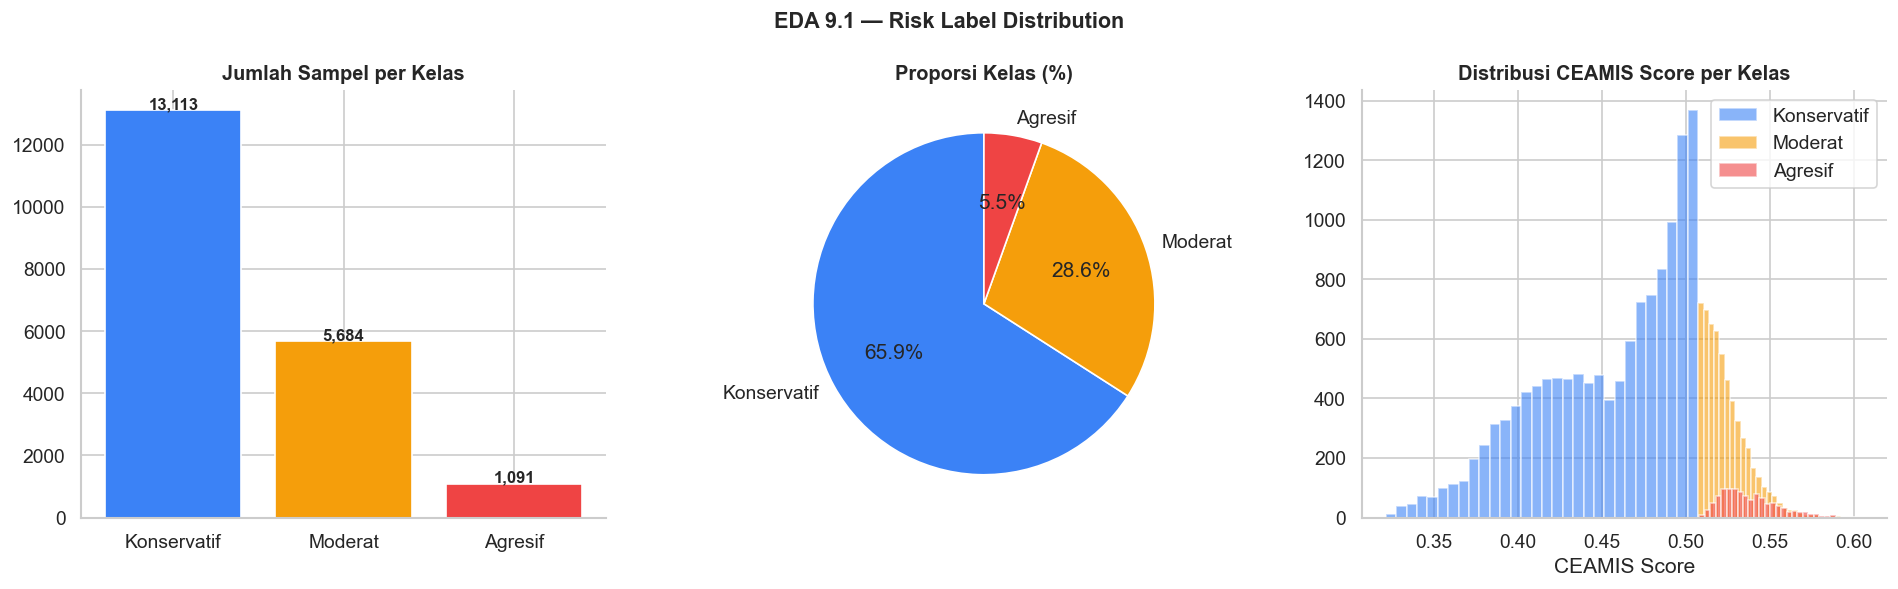

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA 9.1 — Risk Label Distribution', fontsize=13, fontweight='bold')

label_counts = df_final['risk_label'].value_counts().reindex(label_order, fill_value=0)
label_pct    = label_counts / label_counts.sum() * 100

# Bar
colors_bar = [PALETTE[l] for l in label_order]
bars = axes[0].bar(label_order, label_counts.values, color=colors_bar, edgecolor='white')
axes[0].set_title('Jumlah Sampel per Kelas')
for bar, cnt in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{cnt:,}', ha='center', fontsize=10, fontweight='bold')

# Pie
axes[1].pie(label_counts.values, labels=label_order, autopct='%1.1f%%',
            colors=colors_bar, startangle=90)
axes[1].set_title('Proporsi Kelas (%)')

# CEAMIS score distribution per label
for label in label_order:
    subset = df_final[df_final['risk_label'] == label]['ceamis_score']
    axes[2].hist(subset, bins=30, alpha=0.6, label=label, color=PALETTE[label])
axes[2].set_title('Distribusi CEAMIS Score per Kelas')
axes[2].set_xlabel('CEAMIS Score')
axes[2].legend()

plt.tight_layout()
plt.savefig('../visualisasi/eda_06_risk_label_dist.png', bbox_inches='tight', dpi=150)
plt.show()


### 9.2 Rasio Keuangan per Risk Label (Menjawab BQ1 & BQ4)

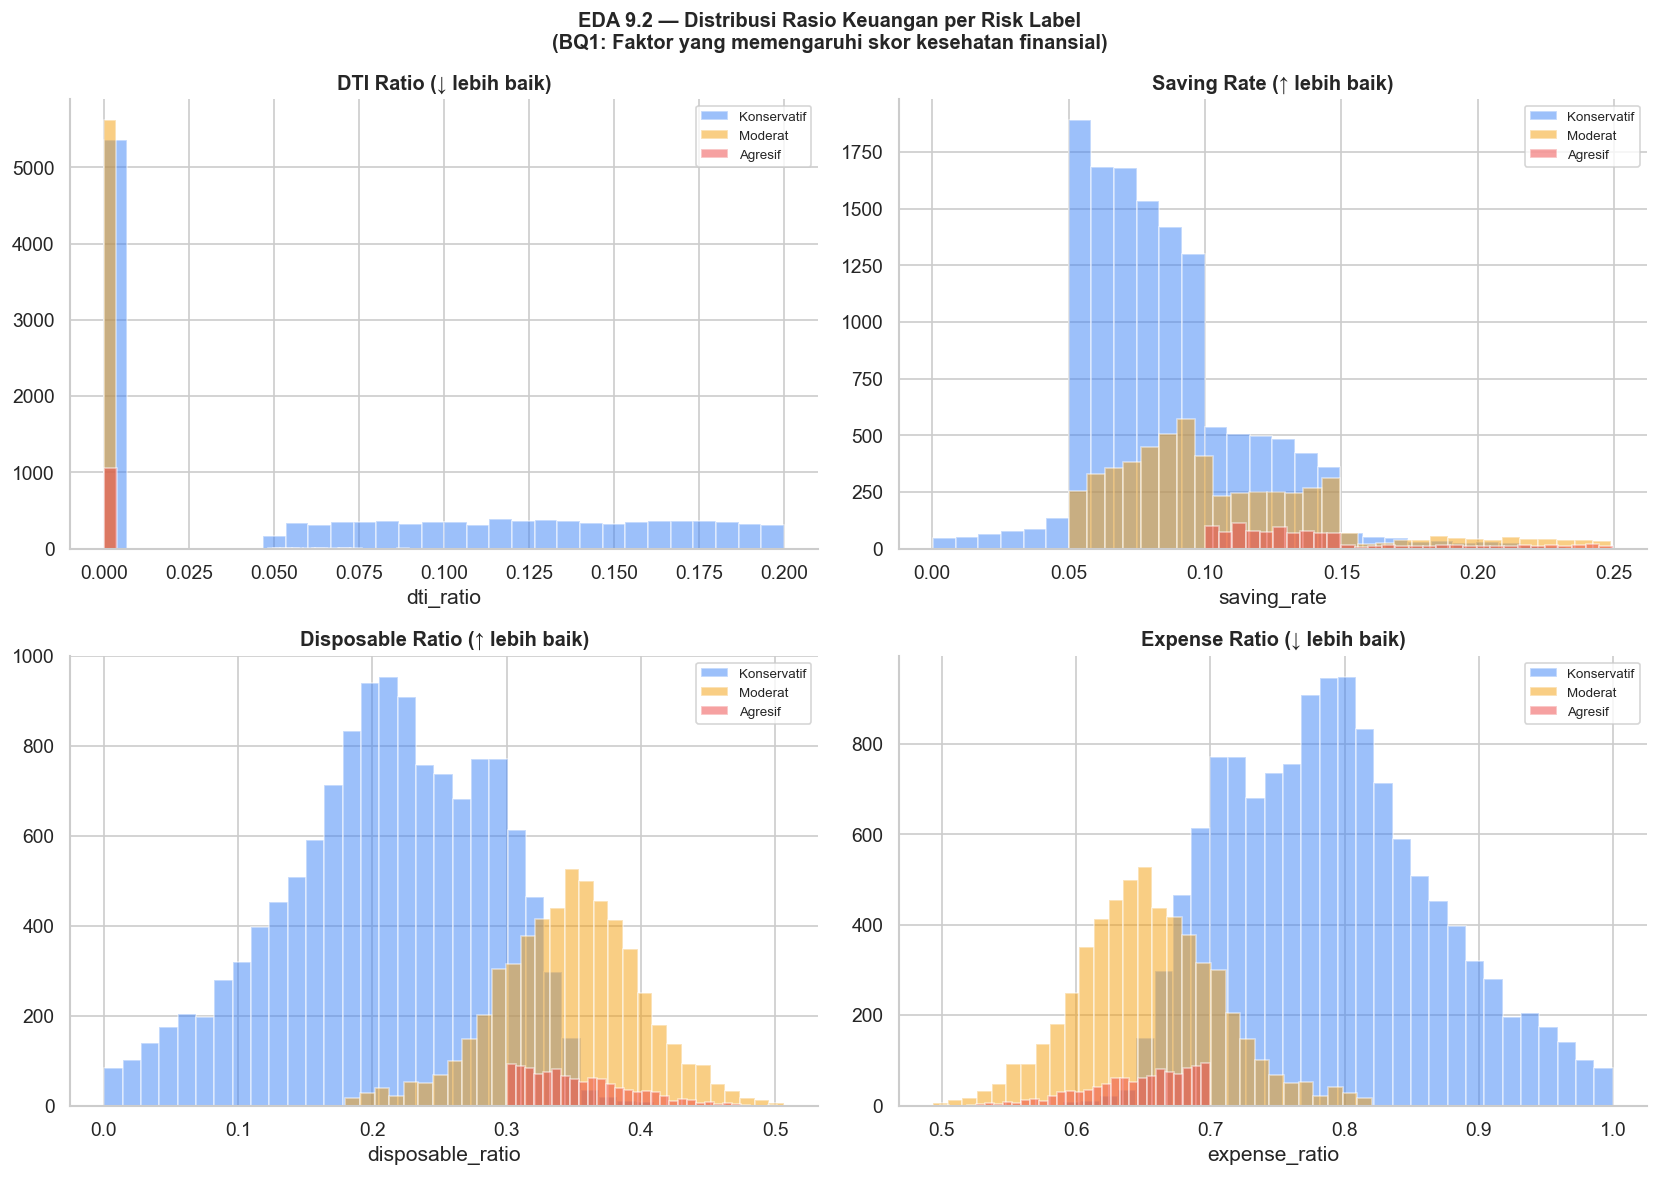

In [73]:
ratio_features = ['dti_ratio', 'saving_rate', 'disposable_ratio', 'expense_ratio']
ratio_titles   = ['DTI Ratio (↓ lebih baik)', 'Saving Rate (↑ lebih baik)',
                  'Disposable Ratio (↑ lebih baik)', 'Expense Ratio (↓ lebih baik)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA 9.2 — Distribusi Rasio Keuangan per Risk Label\n(BQ1: Faktor yang memengaruhi skor kesehatan finansial)', fontsize=12, fontweight='bold')

for ax, feat, title in zip(axes.flat, ratio_features, ratio_titles):
    for label in label_order:
        subset = df_final[df_final['risk_label'] == label][feat]
        ax.hist(subset, bins=30, alpha=0.5, label=label, color=PALETTE[label])
    ax.set_title(title)
    ax.set_xlabel(feat)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../visualisasi/eda_07_rasio_violin.png', bbox_inches='tight', dpi=150)
plt.show()


### 9.3 Profil Segmen Berisiko (Menjawab BQ2)

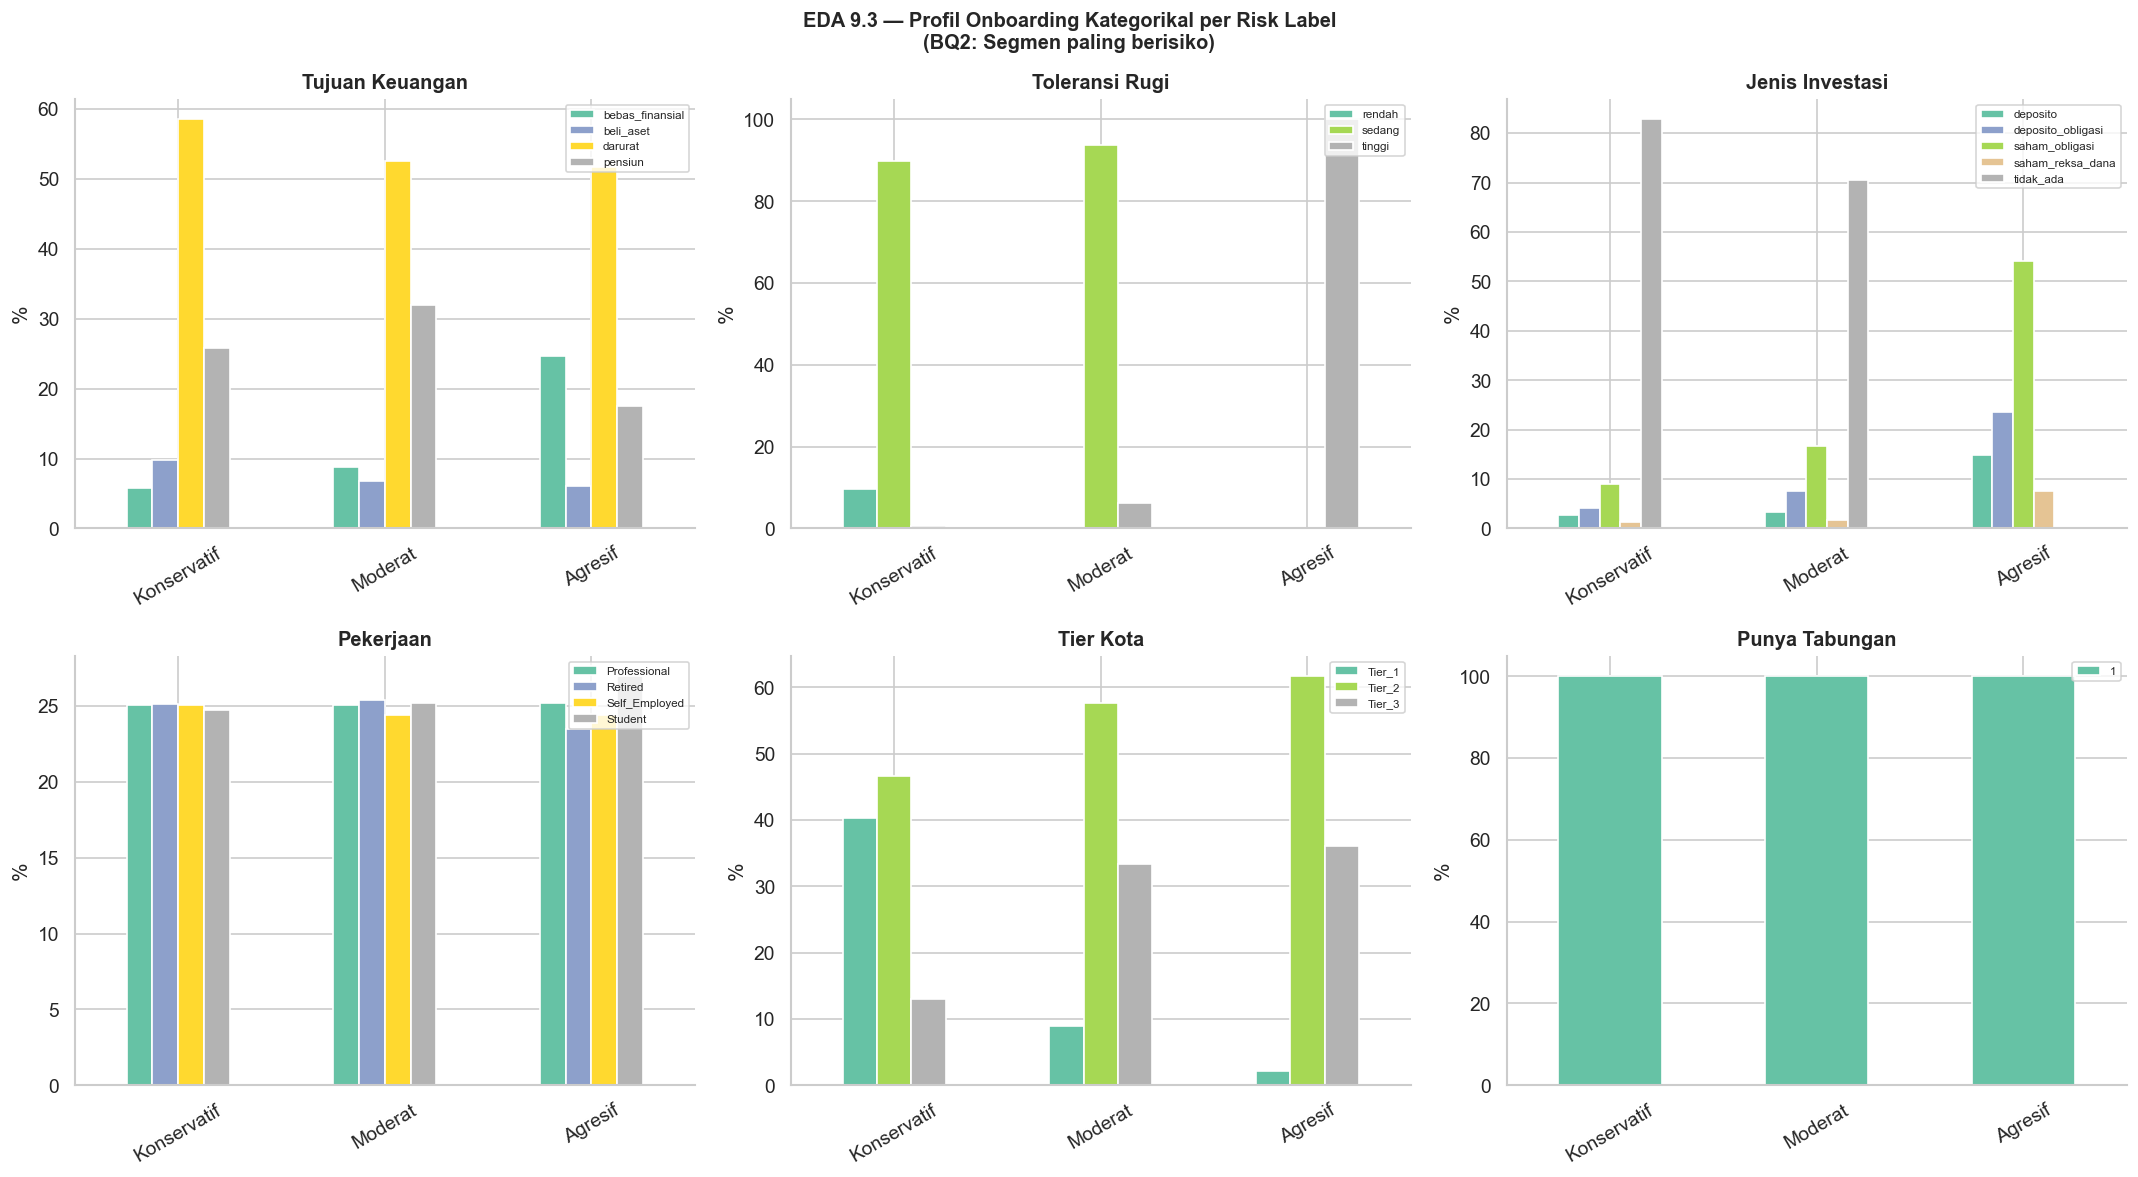

In [74]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA 9.3 — Profil Onboarding Kategorikal per Risk Label\n(BQ2: Segmen paling berisiko)', fontsize=12, fontweight='bold')

cat_features = [
    ('tujuan_keuangan', 'Tujuan Keuangan'),
    ('toleransi_rugi', 'Toleransi Rugi'),
    ('jenis_investasi', 'Jenis Investasi'),
    ('Occupation', 'Pekerjaan'),
    ('City_Tier', 'Tier Kota'),
    ('punya_tabungan', 'Punya Tabungan'),
]

for ax, (feat, title) in zip(axes.flat, cat_features):
    ct = df_final.groupby(['risk_label', feat]).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.reindex(label_order).plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel('%')
    ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig('../visualisasi/eda_08_profil_kategorikal.png', bbox_inches='tight', dpi=150)
plt.show()


### 9.4 Income & Age per Risk Label

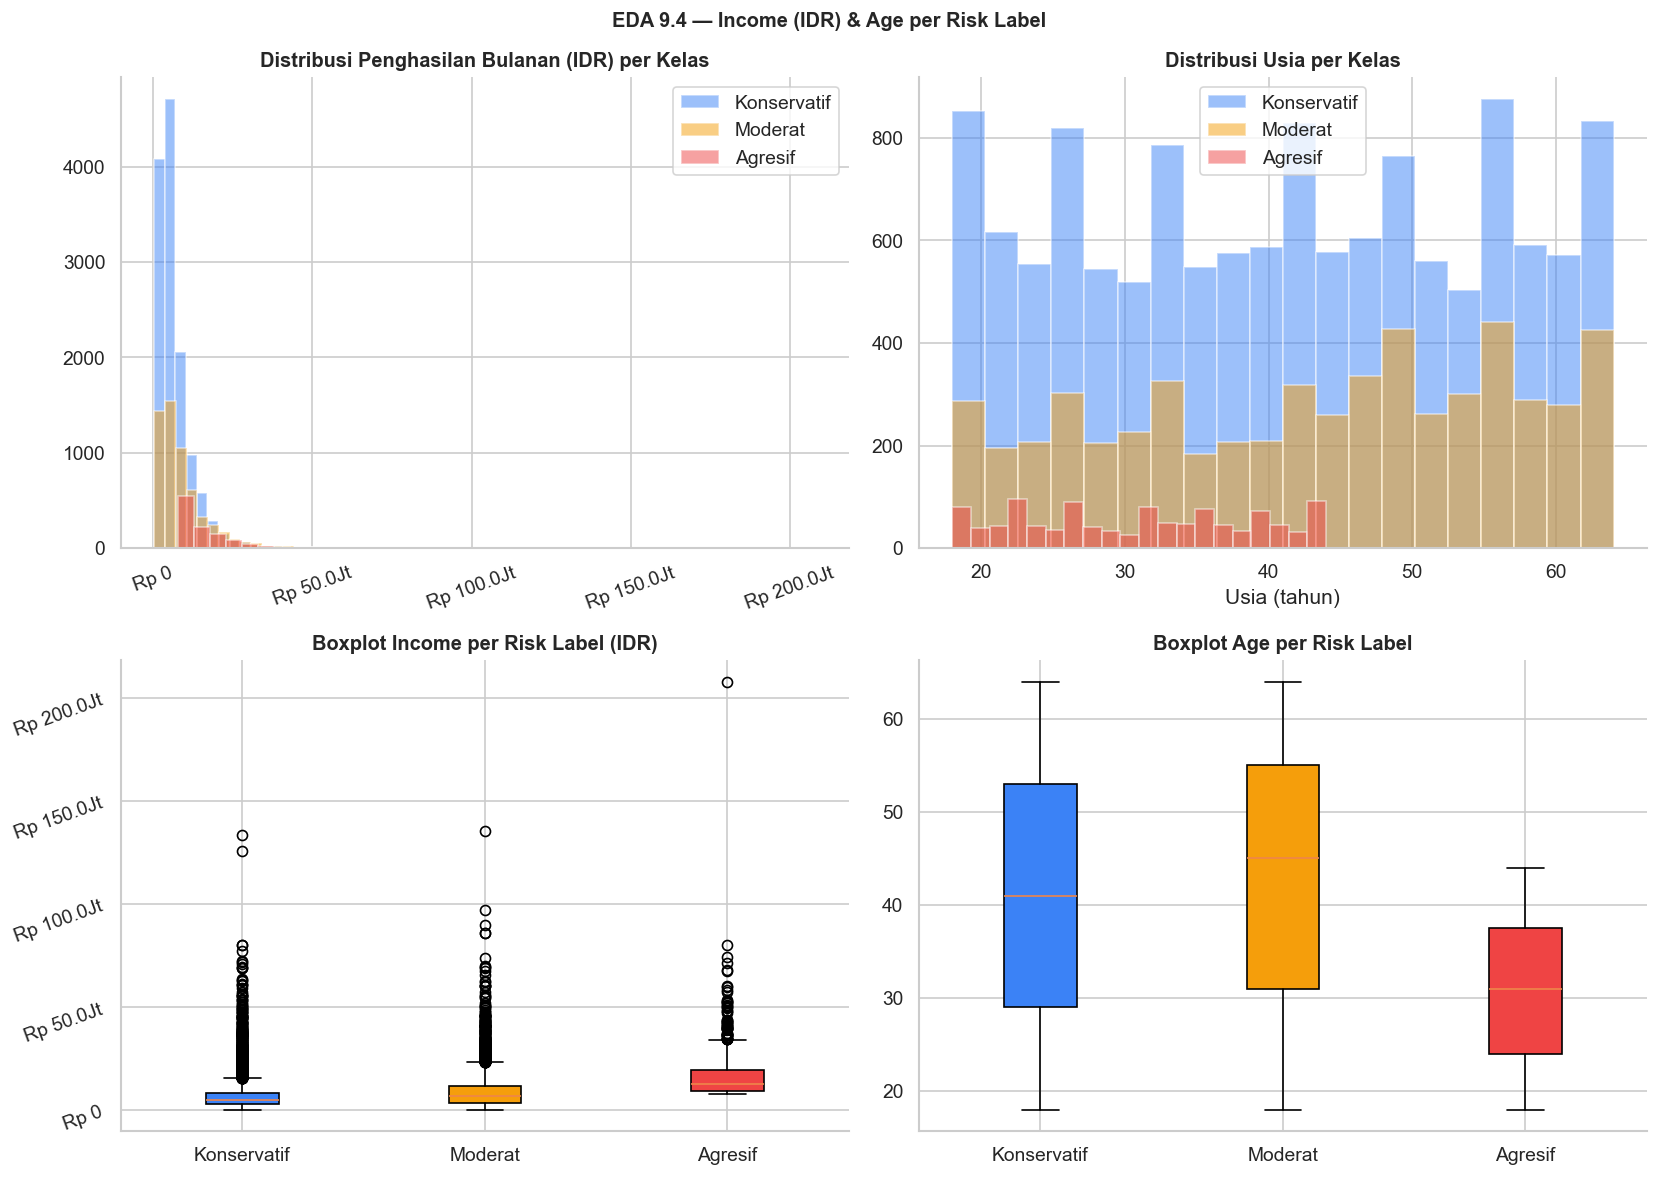

In [75]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA 9.4 — Income (IDR) & Age per Risk Label', fontsize=12, fontweight='bold')

for label in label_order:
    subset_inc = df_final[df_final['risk_label'] == label]['penghasilan_bulanan']
    subset_age = df_final[df_final['risk_label'] == label]['Age']
    axes[0, 0].hist(subset_inc, bins=40, alpha=0.5, label=label, color=PALETTE[label])
    axes[0, 1].hist(subset_age, bins=20, alpha=0.5, label=label, color=PALETTE[label])

axes[0, 0].set_title('Distribusi Penghasilan Bulanan (IDR) per Kelas')
axes[0, 0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_idr))
axes[0, 0].tick_params(axis='x', rotation=20)
axes[0, 0].legend()

axes[0, 1].set_title('Distribusi Usia per Kelas')
axes[0, 1].set_xlabel('Usia (tahun)')
axes[0, 1].legend()

# Boxplot income per label
income_by_label = [df_final[df_final['risk_label'] == l]['penghasilan_bulanan'] for l in label_order]
bp = axes[1, 0].boxplot(income_by_label, labels=label_order, patch_artist=True)
for patch, label in zip(bp['boxes'], label_order):
    patch.set_facecolor(PALETTE[label])
axes[1, 0].set_title('Boxplot Income per Risk Label (IDR)')
axes[1, 0].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_idr))
axes[1, 0].tick_params(axis='y', rotation=20)

# Boxplot age per label
age_by_label = [df_final[df_final['risk_label'] == l]['Age'] for l in label_order]
bp2 = axes[1, 1].boxplot(age_by_label, labels=label_order, patch_artist=True)
for patch, label in zip(bp2['boxes'], label_order):
    patch.set_facecolor(PALETTE[label])
axes[1, 1].set_title('Boxplot Age per Risk Label')

plt.tight_layout()
plt.savefig('../visualisasi/eda_09_income_age_per_label.png', bbox_inches='tight', dpi=150)
plt.show()


### 9.5 Correlation Heatmap — Processed Features

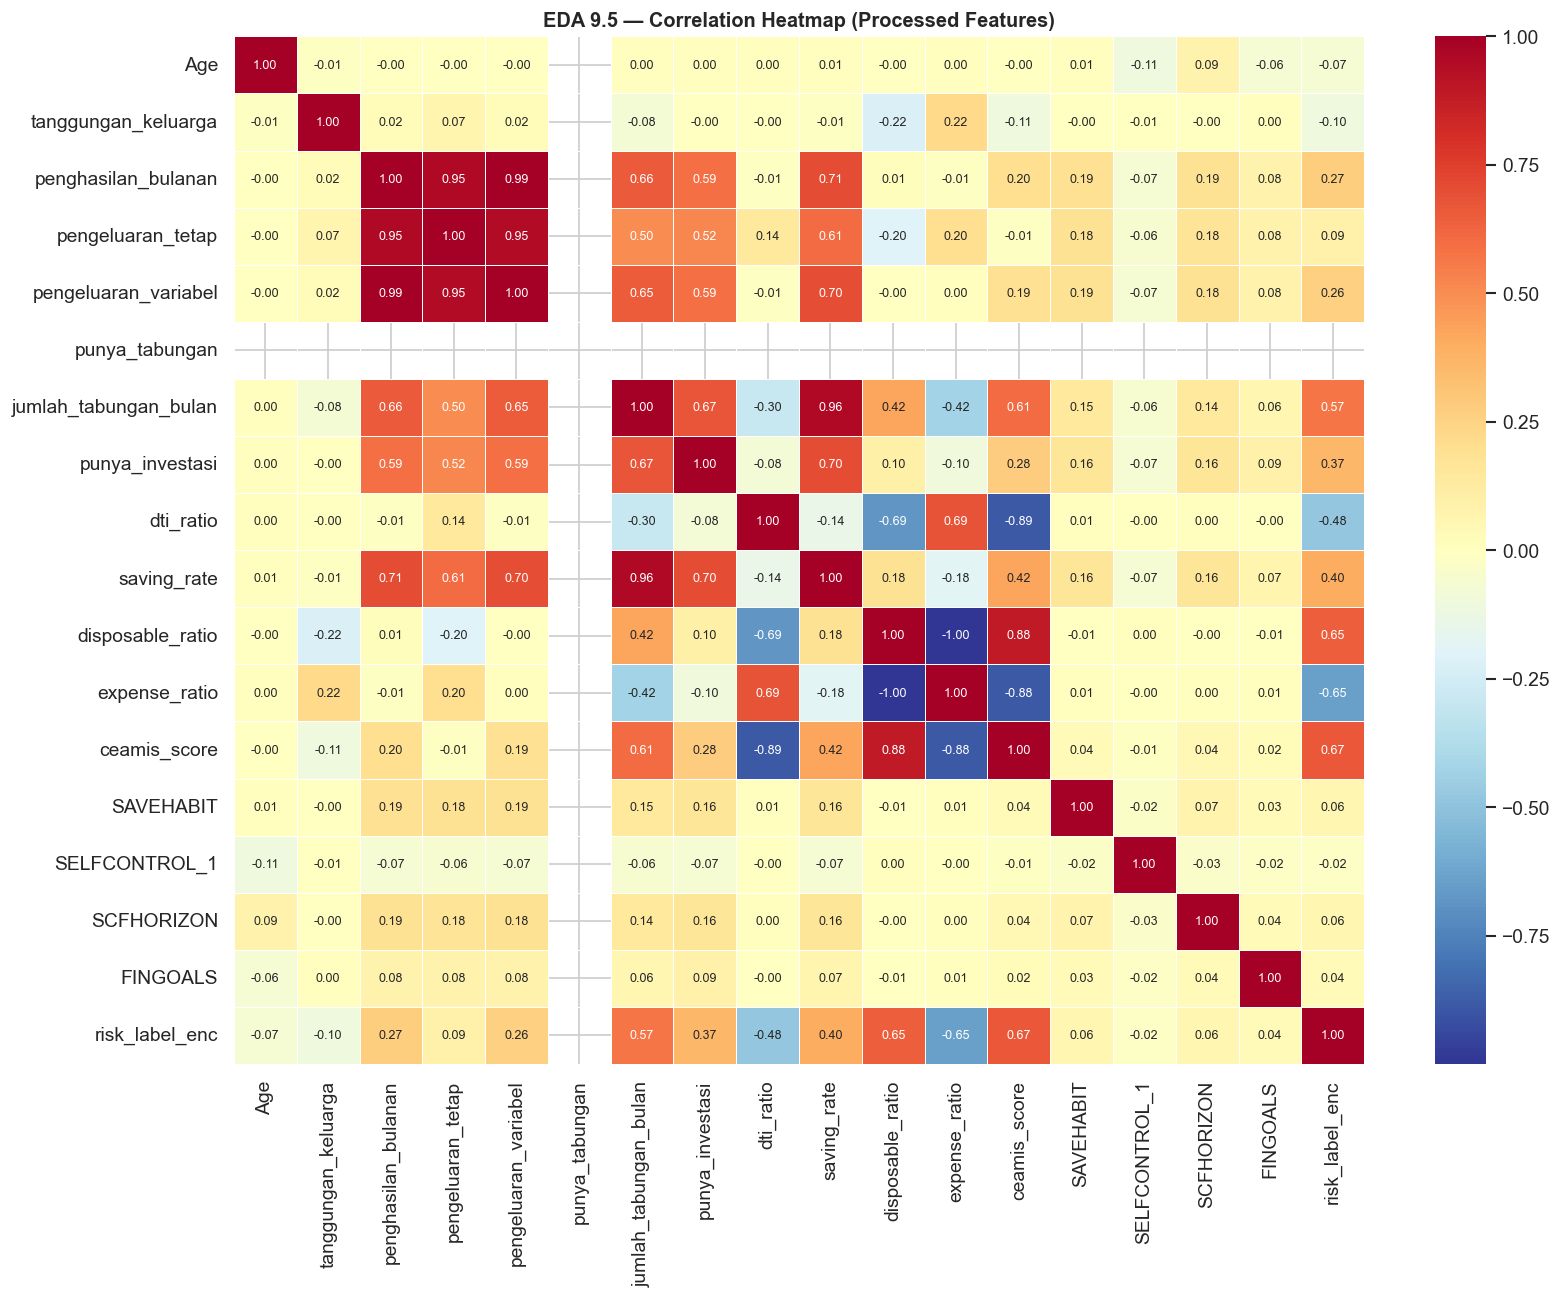

In [76]:
model_features_num = [
    'Age', 'tanggungan_keluarga', 'penghasilan_bulanan', 'pengeluaran_tetap',
    'pengeluaran_variabel', 'punya_tabungan', 'jumlah_tabungan_bulan',
    'punya_investasi', 'dti_ratio', 'saving_rate', 'disposable_ratio',
    'expense_ratio', 'ceamis_score', 'SAVEHABIT', 'SELFCONTROL_1',
    'SCFHORIZON', 'FINGOALS', 'risk_label_enc'
]

corr_proc = df_final[model_features_num].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_proc, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7.5})
ax.set_title('EDA 9.5 — Correlation Heatmap (Processed Features)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualisasi/eda_11_corr_processed.png', bbox_inches='tight', dpi=150)
plt.show()


### 9.6 Feature Importance Proxy — Korelasi Absolut dengan Target

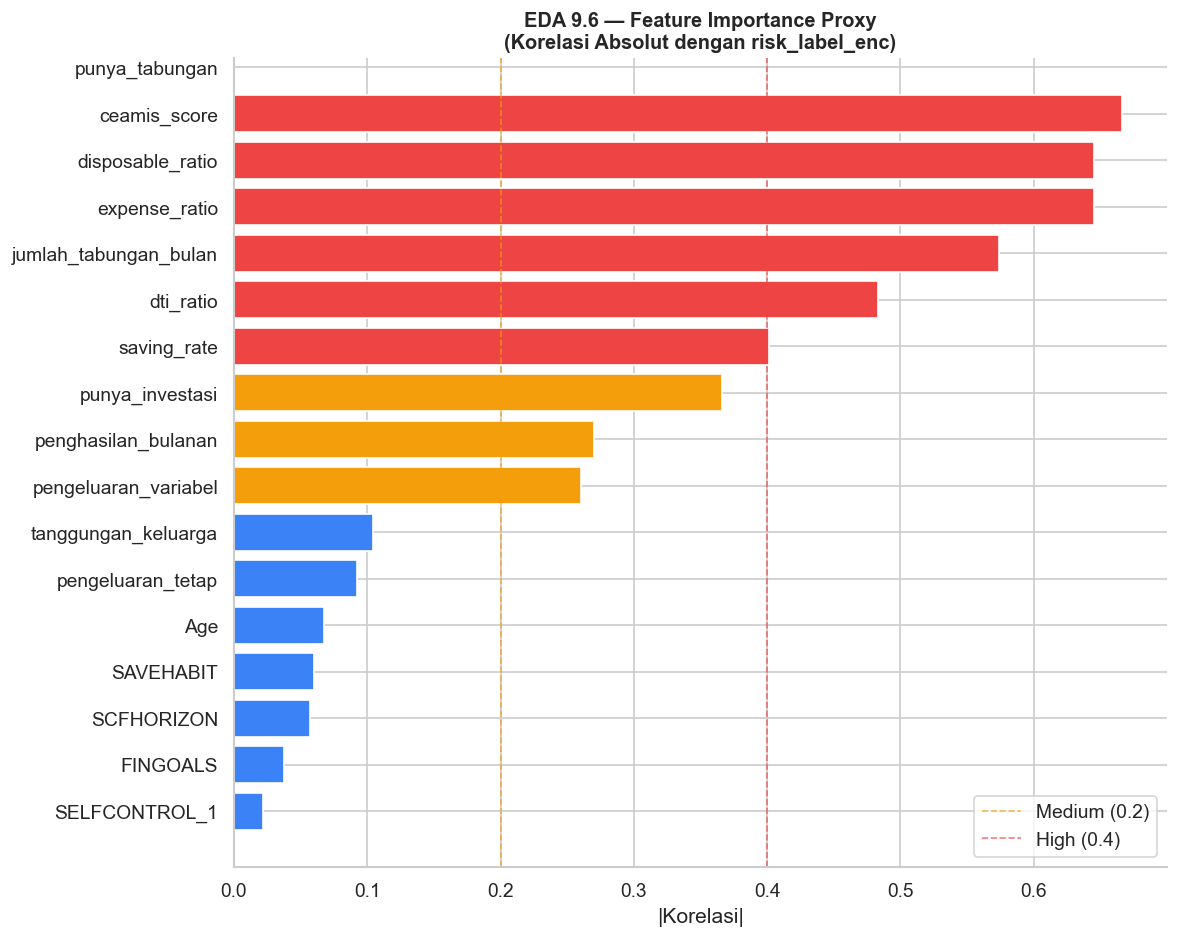

In [77]:
target_corr = df_final[model_features_num].corr()['risk_label_enc'].drop('risk_label_enc')
target_corr_abs = target_corr.abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors_fi = ['#EF4444' if v >= 0.4 else '#F59E0B' if v >= 0.2 else '#3B82F6'
             for v in target_corr_abs.values]
bars = ax.barh(target_corr_abs.index, target_corr_abs.values, color=colors_fi, edgecolor='white')
ax.axvline(0.2, color='#F59E0B', linestyle='--', linewidth=1, alpha=0.7, label='Medium (0.2)')
ax.axvline(0.4, color='#EF4444', linestyle='--', linewidth=1, alpha=0.7, label='High (0.4)')
ax.set_title('EDA 9.6 — Feature Importance Proxy\n(Korelasi Absolut dengan risk_label_enc)', fontsize=12, fontweight='bold')
ax.set_xlabel('|Korelasi|')
ax.legend()
plt.tight_layout()
plt.savefig('../visualisasi/eda_12_feature_importance_proxy.png', bbox_inches='tight', dpi=150)
plt.show()


### 9.7 Scatter Plot — CEAMIS Score vs DTI Ratio

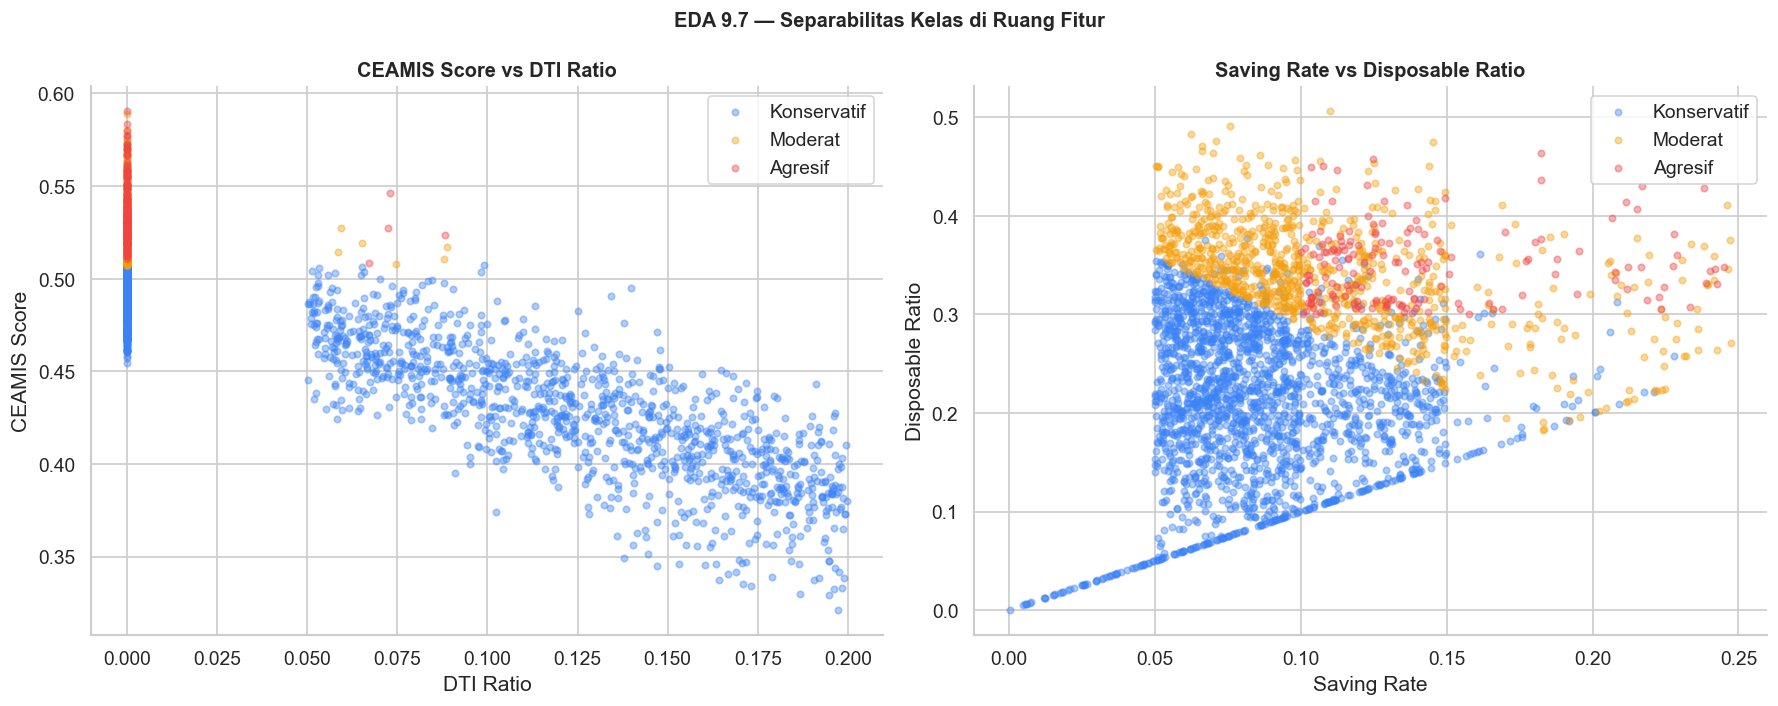

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('EDA 9.7 — Separabilitas Kelas di Ruang Fitur', fontsize=12, fontweight='bold')

sample = df_final.sample(min(3000, len(df_final)), random_state=RANDOM_SEED)

for label in label_order:
    sub = sample[sample['risk_label'] == label]
    axes[0].scatter(sub['dti_ratio'], sub['ceamis_score'],
                    alpha=0.4, s=15, label=label, color=PALETTE[label])
axes[0].set_xlabel('DTI Ratio')
axes[0].set_ylabel('CEAMIS Score')
axes[0].set_title('CEAMIS Score vs DTI Ratio')
axes[0].legend()

for label in label_order:
    sub = sample[sample['risk_label'] == label]
    axes[1].scatter(sub['saving_rate'], sub['disposable_ratio'],
                    alpha=0.4, s=15, label=label, color=PALETTE[label])
axes[1].set_xlabel('Saving Rate')
axes[1].set_ylabel('Disposable Ratio')
axes[1].set_title('Saving Rate vs Disposable Ratio')
axes[1].legend()

plt.tight_layout()
plt.savefig('../visualisasi/eda_13_scatter_separability.png', bbox_inches='tight', dpi=150)
plt.show()


### 9.8 NFWBS Behavior Features per Risk Label

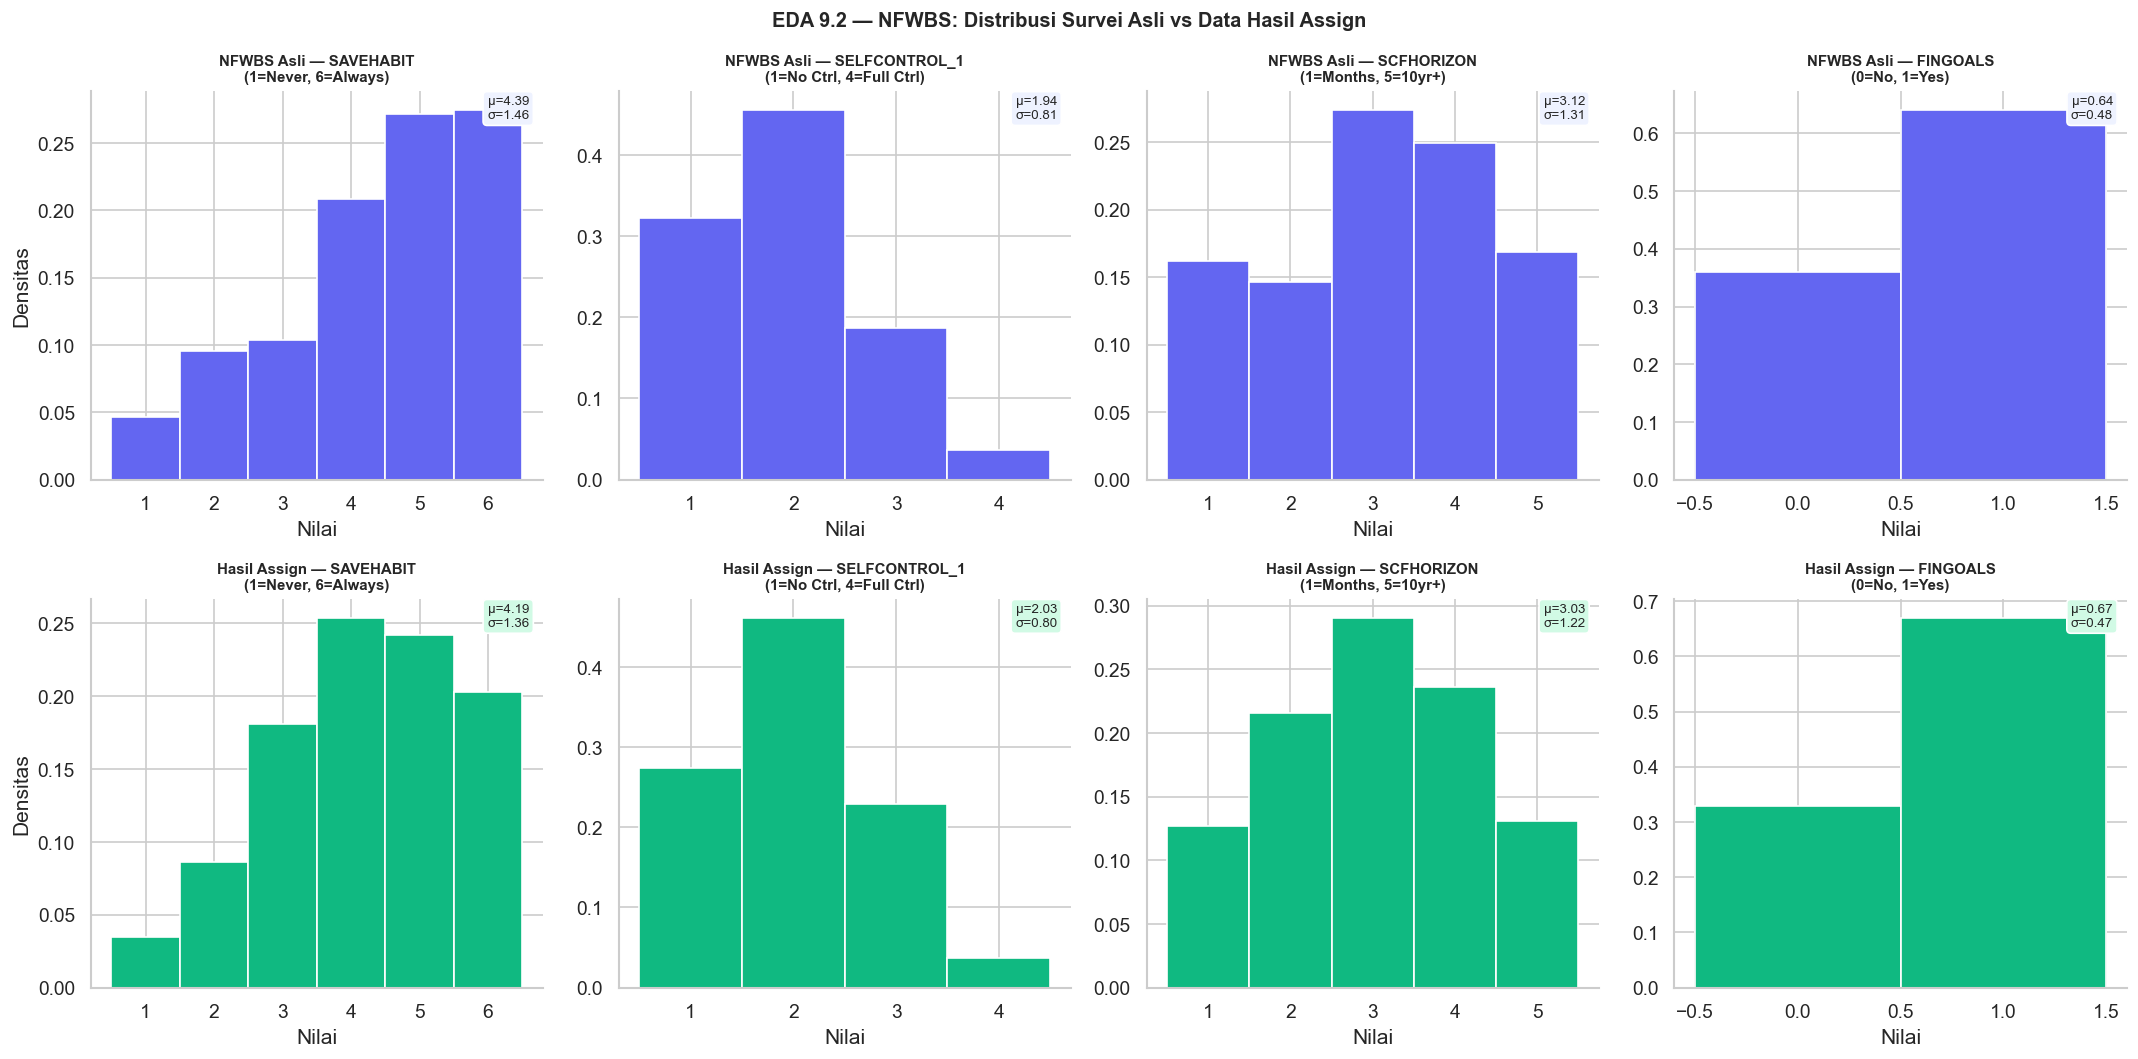

In [79]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('EDA 9.2 — NFWBS: Distribusi Survei Asli vs Data Hasil Assign', fontsize=12, fontweight='bold')

nfwbs_descs = {
    'SAVEHABIT'    : 'SAVEHABIT\n(1=Never, 6=Always)',
    'SELFCONTROL_1': 'SELFCONTROL_1\n(1=No Ctrl, 4=Full Ctrl)',
    'SCFHORIZON'   : 'SCFHORIZON\n(1=Months, 5=10yr+)',
    'FINGOALS'     : 'FINGOALS\n(0=No, 1=Yes)',
}

for i, (col, desc) in enumerate(nfwbs_descs.items()):
    lo, hi = NFWBS_VALID_RANGE[col]

    # Row 0: NFWBS asli
    orig_clean = df_nfwbs[col].dropna()
    axes[0, i].hist(orig_clean, bins=range(lo, hi + 2), color='#6366F1',
                    edgecolor='white', density=True, align='left')
    axes[0, i].set_title(f'NFWBS Asli — {desc}', fontsize=9)
    axes[0, i].set_xlabel('Nilai')
    if i == 0:
        axes[0, i].set_ylabel('Densitas')
    axes[0, i].text(0.97, 0.93, f'μ={orig_clean.mean():.2f}\nσ={orig_clean.std():.2f}',
                    transform=axes[0, i].transAxes, ha='right', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='#EEF2FF'))

    # Row 1: Hasil assign
    assigned_clean = df_final[col]
    axes[1, i].hist(assigned_clean, bins=range(lo, hi + 2), color='#10B981',
                    edgecolor='white', density=True, align='left')
    axes[1, i].set_title(f'Hasil Assign — {desc}', fontsize=9)
    axes[1, i].set_xlabel('Nilai')
    if i == 0:
        axes[1, i].set_ylabel('Densitas')
    axes[1, i].text(0.97, 0.93, f'μ={assigned_clean.mean():.2f}\nσ={assigned_clean.std():.2f}',
                    transform=axes[1, i].transAxes, ha='right', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='#D1FAE5'))

plt.tight_layout()
plt.savefig('../visualisasi/eda_14_nfwbs_distribution_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

### 9.9 Pairplot — Fitur Utama CEAMIS (Sample 1500)

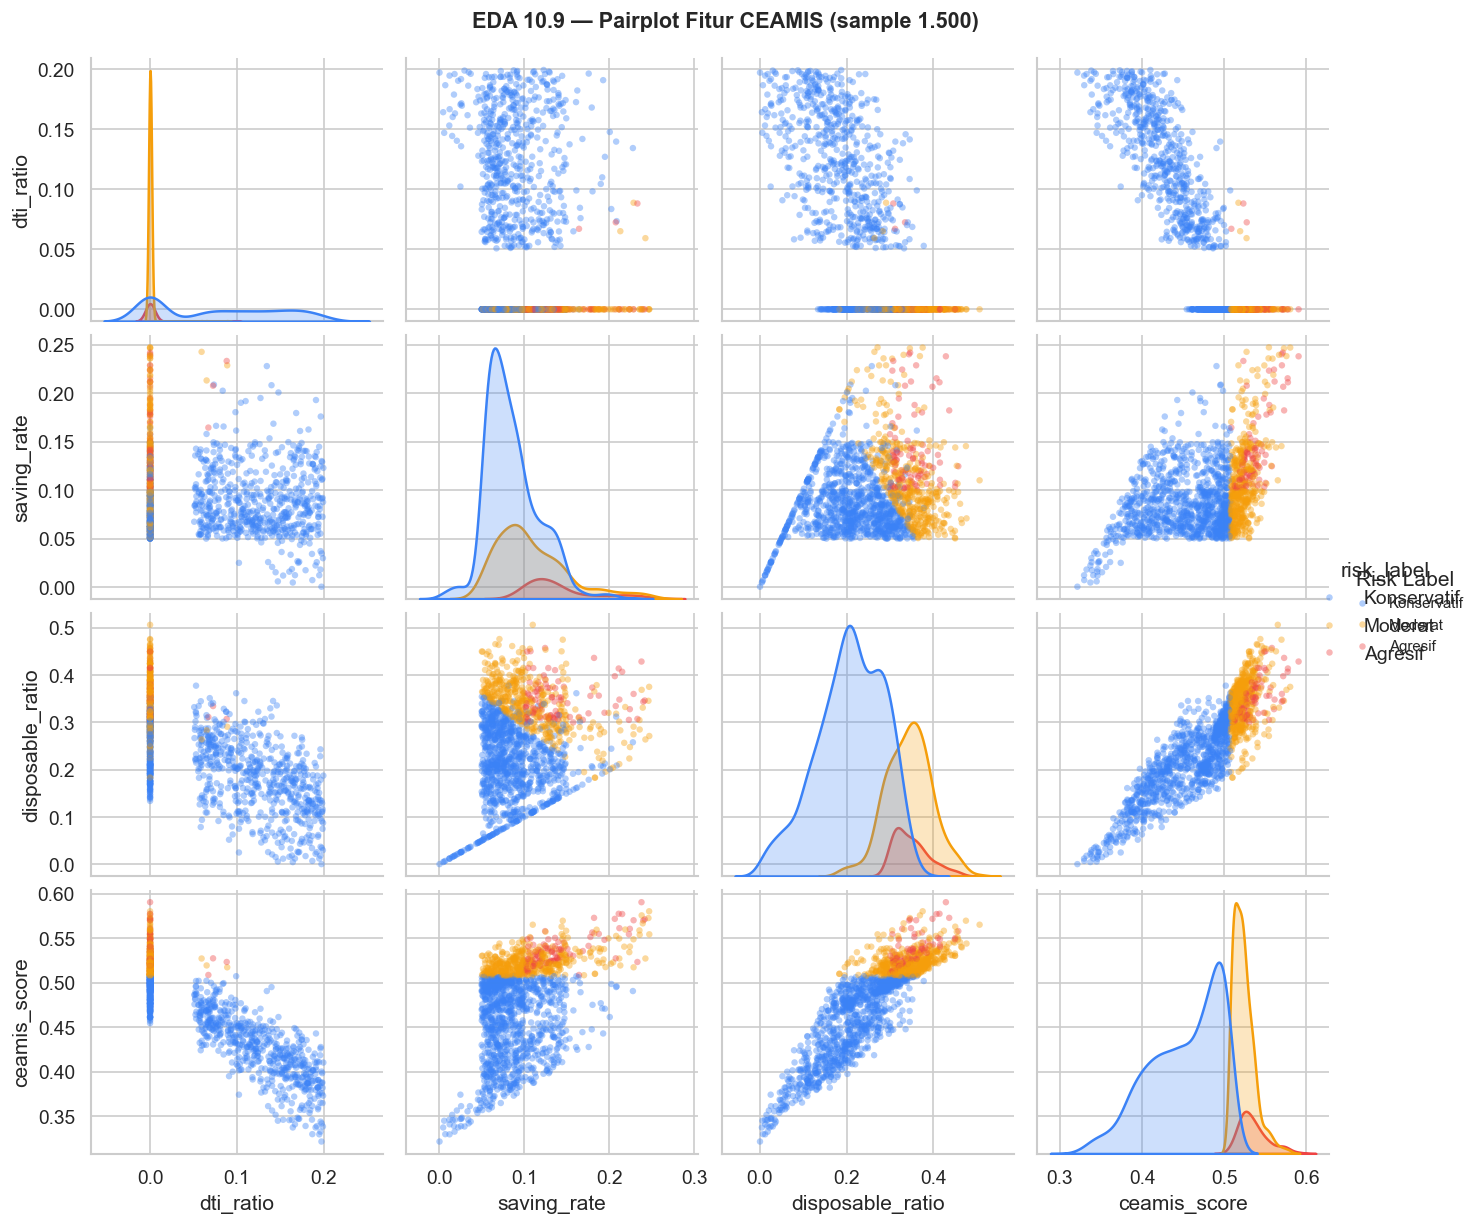

In [80]:
pairplot_cols = ['dti_ratio', 'saving_rate', 'disposable_ratio', 'ceamis_score', 'risk_label']
sample_pp = df_final[pairplot_cols].sample(min(1500, len(df_final)), random_state=RANDOM_SEED)

g = sns.pairplot(
    sample_pp,
    hue='risk_label',
    hue_order=label_order,
    palette=PALETTE,
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15, 'edgecolor': 'none'},
    diag_kws={'linewidth': 1.5}
)
g.figure.suptitle('EDA 10.9 — Pairplot Fitur CEAMIS (sample 1.500)', y=1.02,
                  fontsize=13, fontweight='bold')
g.add_legend(title='Risk Label', fontsize=9)

plt.savefig('../visualisasi/eda_14_pairplot.png', bbox_inches='tight')
plt.show()

---
## 10. Data Dictionary — Handoff ke AI Engineer

Semua kolom output dijelaskan di sini. **Kolom moneter dalam IDR (Rupiah).**


In [81]:
data_dict = {
    'Kolom': [
        # Identitas
        'Age', 'Occupation', 'City_Tier',
        # Onboarding moneter (IDR)
        'penghasilan_bulanan', 'pengeluaran_tetap', 'pengeluaran_variabel', 'total_pengeluaran',
        # Tabungan & Investasi
        'punya_tabungan', 'jumlah_tabungan_bulan',
        'punya_investasi', 'jenis_investasi',
        # Profil Keuangan
        'tujuan_keuangan', 'toleransi_rugi', 'tanggungan_keluarga',
        # Rasio CEAMIS
        'dti_ratio', 'saving_rate', 'disposable_ratio', 'expense_ratio', 'ceamis_score',
        # NFWBS Behavior (heuristik)
        'SAVEHABIT', 'SELFCONTROL_1', 'SCFHORIZON', 'FINGOALS',
        # Encoded
        'toleransi_rugi_enc', 'tujuan_keuangan_enc',
        'inv_*', 'occ_*',
        # Target
        'risk_label', 'risk_label_enc',
    ],
    'Tipe': [
        'int', 'str', 'str',
        'float (IDR)', 'float (IDR)', 'float (IDR)', 'float (IDR)',
        'int (0/1)', 'float',
        'int (0/1)', 'str',
        'str (enum)', 'str (enum)', 'int',
        'float [0,1]', 'float [0,1]', 'float [0,1]', 'float [0,2]', 'float [0,1]',
        'int [1,4]', 'int [1,5]', 'int [1,6]', 'int [1,4]',
        'int [0,2]', 'int [0,3]',
        'int (0/1)', 'int (0/1)',
        'str', 'int (0/1/2)',
    ],
    'Satuan': [
        'tahun', 'kategori', 'kategori',
        'IDR/bulan', 'IDR/bulan', 'IDR/bulan', 'IDR/bulan',
        'boolean', 'bulan',
        'boolean', 'kategori',
        'enum', 'enum', 'orang',
        'rasio', 'rasio', 'rasio', 'rasio', 'skor [0,1]',
        'skala 1-4', 'skala 1-5', 'skala 1-6', 'skala 1-4',
        'ordinal', 'ordinal',
        'boolean OHE', 'boolean OHE',
        'label', 'encoded',
    ],
    'Sumber': [
        'data.csv', 'data.csv', 'data.csv',
        'derived', 'derived', 'derived', 'derived',
        'derived', 'derived', 'derived', 'derived',
        'derived', 'derived', 'derived',
        'derived', 'derived', 'derived', 'derived', 'derived',
        'NFWBS PUF 2016 (real)', 'NFWBS PUF 2016 (real)', 'NFWBS PUF 2016 (real)', 'NFWBS PUF 2016 (real)',
        'encoded', 'encoded', 'OHE', 'OHE',
        'generated', 'generated',
    ],
    'Keterangan': [
        'Usia pengguna (18–70 tahun)',
        'Profesi: Self_Employed / Retired / Student / Professional',
        'Tier kota tempat tinggal: Tier_1 / Tier_2 / Tier_3',
        'Pendapatan bulanan dalam Rupiah Indonesia (IDR)',
        'Pengeluaran tetap/fixed: Rent+Loan+Insurance+Utilities+Education (IDR)',
        'Pengeluaran variabel: Groceries+Transport+Eating_Out+Entertainment+Healthcare+Misc (IDR)',
        'Total pengeluaran bulanan = tetap + variabel (IDR)',
        '1 = punya tabungan (Desired_Savings > 0), 0 = tidak',
        'Estimasi dana darurat dalam satuan bulan pengeluaran (cap 36 bulan)',
        '1 = aktif berinvestasi (berdasarkan proxy disposable & saving), 0 = tidak',
        'Jenis investasi: tidak_ada / reksa_dana / deposito / saham_reksa_dana / saham_obligasi / deposito_obligasi',
        'Tujuan keuangan utama: darurat / pensiun / beli_aset / bebas_finansial',
        'Toleransi risiko investasi: rendah / sedang / tinggi',
        'Jumlah tanggungan keluarga (0–10 orang)',
        'Debt-to-Income Ratio = Loan_Repayment / Income. Cap [0,1]. >0.5 = kritis',
        'Saving Rate = Desired_Savings / Income. Cap [0,1]. <0.1 = rendah',
        'Sisa pendapatan = Disposable_Income / Income. Makin tinggi makin sehat',
        'Expense Ratio = total_pengeluaran / Income. >0.8 = risiko cashflow negatif',
        'CEAMIS Score = 0.4*(1-DTI) + 0.35*saving_rate + 0.25*disposable_ratio. [0,1]',
        'Kebiasaan menabung (NFWBS heuristik): 1=tidak pernah … 4=selalu',
        'Kendali pengeluaran (NFWBS): 1=tidak terkontrol … 5=sangat terkontrol',
        'Horizon perencanaan keuangan (NFWBS): 1=beberapa bulan … 6=10+ tahun',
        'Tujuan finansial tertulis (NFWBS): 1=tidak ada … 4=tujuan jelas tertulis',
        'toleransi_rugi encoded: rendah=0, sedang=1, tinggi=2',
        'tujuan_keuangan encoded: darurat=0, pensiun=1, beli_aset=2, bebas_finansial=3',
        'One-hot encoding jenis_investasi (5 kolom: inv_deposito, inv_reksa_dana, dst)',
        'One-hot encoding Occupation (4 kolom: occ_Professional, occ_Retired, dst)',
        'Risk label target: Konservatif / Moderat / Agresif',
        'Target encoded: 0=Konservatif, 1=Moderat, 2=Agresif',
    ],
    'Nilai_Kritis': [
        '18–70', '-', '-',
        'Median ≈ Rp 5,8Jt', '-', '-', '-',
        '0 atau 1', '< 3 = darurat',
        '0 atau 1', '-',
        '4 kategori', '3 level', '0–10',
        '> 0.5 → Konservatif', '< 0.1 = rendah', '< 0.1 = kritis', '> 0.8 = warning',
        '< 0.35 = Konservatif, > 0.65 = Agresif',
        '1–4', '1–5', '1–6', '1–4',
        '0–2', '0–3',
        '0 atau 1', '0 atau 1',
        '3 kelas', '0 / 1 / 2',
    ]
}

df_dict = pd.DataFrame(data_dict)
pd.set_option('display.max_colwidth', 90)
pd.set_option('display.max_rows', 50)
print('=== DATA DICTIONARY — Model 3 Risk Profile (IDR) ===')
print(f'Total kolom terdokumentasi: {len(data_dict["Kolom"])}')
df_dict


=== DATA DICTIONARY — Model 3 Risk Profile (IDR) ===
Total kolom terdokumentasi: 29


,Kolom,Tipe,Satuan,Sumber,Keterangan,Nilai_Kritis
0,Age,int,tahun,data.csv,Usia pengguna (18–70 tahun),18–70
1,Occupation,str,kategori,data.csv,Profesi: Self_Employed / Retired / Student / Professional,-
2,City_Tier,str,kategori,data.csv,Tier kota tempat tinggal: Tier_1 / Tier_2 / Tier_3,-
3,penghasilan_bulanan,float (IDR),IDR/bulan,derived,Pendapatan bulanan dalam Rupiah Indonesia (IDR),"Median ≈ Rp 5,8Jt"
4,pengeluaran_tetap,float (IDR),IDR/bulan,derived,Pengeluaran tetap/fixed: Rent+Loan+Insurance+Utilities+Education (IDR),-
5,pengeluaran_variabel,float (IDR),IDR/bulan,derived,Pengeluaran variabel: Groceries+Transport+Eating_Out+Entertainment+Healthcare+Misc (IDR),-
6,total_pengeluaran,float (IDR),IDR/bulan,derived,Total pengeluaran bulanan = tetap + variabel (IDR),-
7,punya_tabungan,int (0/1),boolean,derived,"1 = punya tabungan (Desired_Savings > 0), 0 = tidak",0 atau 1
8,jumlah_tabungan_bulan,float,bulan,derived,Estimasi dana darurat dalam satuan bulan pengeluaran (cap 36 bulan),< 3 = darurat
9,punya_investasi,int (0/1),boolean,derived,"1 = aktif berinvestasi (berdasarkan proxy disposable & saving), 0 = tidak",0 atau 1


---
## 11. Train-Test Split & Export


In [82]:
# Stratified split 80:20
split_counts = df_final['risk_label'].value_counts()
if split_counts.min() < 2 or df_final['risk_label'].nunique() < 2:
    raise ValueError('Tidak cukup sampel untuk stratified split.')

df_train, df_test = train_test_split(
    df_final, test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=df_final['risk_label']
)
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f'Train shape : {df_train.shape}')
print(f'Test shape  : {df_test.shape}')
print('\nTrain distribution:')
print(df_train['risk_label'].value_counts(normalize=True).reindex(label_order).round(4))
print('\nTest distribution:')
print(df_test['risk_label'].value_counts(normalize=True).reindex(label_order).round(4))


Train shape : (15910, 36)
Test shape  : (3978, 36)

Train distribution:
risk_label
Konservatif    0.6593
Moderat        0.2858
Agresif        0.0549
Name: proportion, dtype: float64

Test distribution:
risk_label
Konservatif    0.6594
Moderat        0.2858
Agresif        0.0548
Name: proportion, dtype: float64


In [83]:
# Export CSV
df_final.to_csv('../data/data_bersih/processed_onboarding.csv', index=False)
df_train.to_csv('../data/data_bersih/train_processed_onboarding.csv', index=False)
df_test.to_csv('../data/data_bersih/test_processed_onboarding.csv', index=False)

print('Export selesai:')
print(f'  processed_onboarding.csv       → {len(df_final):,} baris, {df_final.shape[1]} kolom')
print(f'  train_processed_onboarding.csv → {len(df_train):,} baris')
print(f'  test_processed_onboarding.csv  → {len(df_test):,} baris')
print('\nSemua nilai moneter dalam IDR (Rupiah Indonesia).')


Export selesai:
  processed_onboarding.csv       → 19,888 baris, 36 kolom
  train_processed_onboarding.csv → 15,910 baris
  test_processed_onboarding.csv  → 3,978 baris

Semua nilai moneter dalam IDR (Rupiah Indonesia).


---
## 12. Feature Reference — Siap Pakai untuk AI Engineer


In [84]:
FEATURE_COLS_NUMERIC = [
    'Age', 'tanggungan_keluarga',
    'penghasilan_bulanan',      # IDR
    'pengeluaran_tetap',        # IDR
    'pengeluaran_variabel',     # IDR
    'punya_tabungan',
    'jumlah_tabungan_bulan',
    'punya_investasi',
    'dti_ratio',
    'saving_rate',
    'disposable_ratio',
    'expense_ratio',
    'ceamis_score',
    'SAVEHABIT',       # dari NFWBS PUF 2016 asli
    'SELFCONTROL_1',   # dari NFWBS PUF 2016 asli
    'SCFHORIZON',      # dari NFWBS PUF 2016 asli
    'FINGOALS',        # dari NFWBS PUF 2016 asli
    'toleransi_rugi_enc',
    'tujuan_keuangan_enc',
]

FEATURE_COLS_OHE = (
    [c for c in df_final.columns if c.startswith('inv_')] +
    [c for c in df_final.columns if c.startswith('occ_')]
)

ALL_FEATURES = FEATURE_COLS_NUMERIC + FEATURE_COLS_OHE
TARGET_COL   = 'risk_label_enc'
TARGET_RAW   = 'risk_label'

print('=== FEATURE REFERENCE untuk AI Engineer ===')
print(f'\nTotal features     : {len(ALL_FEATURES)}')
print(f'Numeric features   : {len(FEATURE_COLS_NUMERIC)}')
print(f'OHE features       : {len(FEATURE_COLS_OHE)}')
print(f'Target (encoded)   : {TARGET_COL} — 0=Konservatif, 1=Moderat, 2=Agresif')
print(f'Target (readable)  : {TARGET_RAW}')
print('\nCatatan:')
print('  - Semua kolom moneter dalam IDR (Rupiah Indonesia)')
print('  - Kurs konversi: 1 INR = Rp', round(INR_TO_IDR, 2))
print('  - ceamis_score bisa dipakai sebagai fitur DAN interpretasi bisnis')
print('  - Jika class imbalance > 2:1, gunakan class_weight="balanced" atau SMOTE')


=== FEATURE REFERENCE untuk AI Engineer ===

Total features     : 28
Numeric features   : 19
OHE features       : 9
Target (encoded)   : risk_label_enc — 0=Konservatif, 1=Moderat, 2=Agresif
Target (readable)  : risk_label

Catatan:
  - Semua kolom moneter dalam IDR (Rupiah Indonesia)
  - Kurs konversi: 1 INR = Rp 192.77
  - ceamis_score bisa dipakai sebagai fitur DAN interpretasi bisnis
  - Jika class imbalance > 2:1, gunakan class_weight="balanced" atau SMOTE


---
## Summary

| Output File | Baris | Kolom | Keterangan |
|---|---|---|---|
| `processed_onboarding.csv` | ~20.000 | lihat shape | Full dataset, nilai moneter dalam IDR |
| `train_processed_onboarding.csv` | ~16.000 (80%) | sama | Training set, stratified |
| `test_processed_onboarding.csv` | ~4.000 (20%) | sama | Test set, stratified |

### Catatan DS
- Semua nilai moneter dikonversi dari INR ke **IDR** (1 INR ≈ Rp 192,77)
- `risk_label_enc` adalah target utama (0/1/2) — 100% rule-based dari CEAMIS rasio
- Kolom **NFWBS diisi dari sampling empiris data survei NFWBS PUF 2016 asli** (6.394 responden), bukan heuristik buatan
- Setiap baris di-assign berdasarkan distribusi nyata `agecat × income_quartile`
- Data Dictionary tersedia di Section 10

### Pertanyaan Bisnis yang Dapat Dijawab dari Dataset Ini
| BQ | Kolom Kunci |
|---|---|
| BQ1 — Skor kesehatan finansial | `ceamis_score`, `dti_ratio`, `saving_rate` |
| BQ2 — Segmen berisiko | `risk_label` × `Age`, `Occupation`, `tanggungan_keluarga` |
| BQ3 — Cashflow negatif | `disposable_ratio`, `expense_ratio`, `pengeluaran_variabel` |
| BQ4 — Komposisi pengeluaran | `pengeluaran_tetap` vs `pengeluaran_variabel` vs `saving_rate` |
| BQ8 — Rekomendasi efektif | `risk_label`, `toleransi_rugi`, `tujuan_keuangan` |
| BQ9 — Trigger recovery plan | `ceamis_score < 0.35` atau `dti_ratio > 0.50` atau `jumlah_tabungan_bulan < 3` |
